#  NeuroLens: Lightweight, Explainable, Uncertainty-Aware and Robust Brain Tumor Classification for Low-Resource Healthcare Environments

---

> ** Medical Disclaimer:** This system is an AI-assisted research tool developed strictly for **educational and research purposes**. It is **not** a certified medical diagnostic system and must **not** replace evaluation by qualified healthcare professionals. All predictions must be reviewed by licensed medical practitioners.

---

##  Project Overview

**NeuroLens** is a complete publication-oriented research pipeline for brain tumor classification from MRI images, addressing four core challenges in clinical AI deployment:

| Pillar | Description |
|--------|-------------|
|  **Lightweight** | High accuracy with low computational cost |
|  **Explainable** | Dual XAI (Grad-CAM++ + Integrated Gradients) with Explanation Agreement Score |
|  **Uncertainty-Aware** | MC Dropout uncertainty estimation with calibrated reliability |
|  **Robust** | Evaluated under realistic MRI perturbations |

### Research Phases
| # | Phase | Purpose |
|---|-------|---------|
| 1 | Project Audit & Baseline Setup | Document existing system |
| 2 | Baseline Experiment | Record ground-truth baseline metrics |
| 3 | Lightweight Model Comparison | Find efficient best model |
| 4 | Explainable AI (XAI) | Grad-CAM++ + Integrated Gradients |
| 5 | Uncertainty Estimation | MC Dropout reliability scoring |
| 6 | Robustness Testing | Perturbation analysis |
| 7 | External Validation | Generalization to unseen dataset |
| 8 | Low-Resource Evaluation | Deployment feasibility |
| 9 | Ablation Study | Component contribution analysis |

---
##  PHASE 1 — PROJECT AUDIT & BASELINE SETUP

**Objective:** Thoroughly document the existing project before any modifications.  
**Research paper sections supported:** Dataset & Preprocessing, Experimental Setup


In [1]:
# Uncomment below if running for the first time:
# !pip install torch torchvision captum scipy psutil --quiet

import os, sys, json, copy, random, time, warnings, gc
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')

# Core Scientific
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Image Processing
from PIL import Image
import cv2

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import (
    resnet50, ResNet50_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights,
)

# Scikit-learn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc, brier_score_loss
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

# System monitoring
import psutil

print(" All libraries imported successfully!")
print(f"   PyTorch  : {torch.__version__}")
print(f"   Python   : {sys.version.split()[0]}")


 All libraries imported successfully!
   PyTorch  : 2.10.0+cu128
   Python   : 3.12.13


In [2]:
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Device        : {device}")
if torch.cuda.is_available():
    print(f"   GPU Name     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"   CUDA         : {torch.version.cuda}")
else:
    print("   (CPU-only — this is a valid low-resource scenario)")


  Device        : cuda
   GPU Name     : Tesla T4
   VRAM         : 15.6 GB
   CUDA         : 12.8


In [3]:
DATASET_PATH  = "/kaggle/input/datasets/potterboy1991/brain-tumor-mri-dataset/Brain Tumor MRI Dataset"
TRAIN_PATH    = os.path.join(DATASET_PATH, "Training")
TEST_PATH     = os.path.join(DATASET_PATH, "Testing")
EXTERNAL_PATH = "/kaggle/input/datasets/potterboy1991/external-brain-tumor-dataset/external_brain_tumor_dataset/testing"

IMG_SIZE         = 224
BATCH_SIZE       = 32
NUM_EPOCHS       = 30
HEAD_EPOCHS      = 8
FINETUNE_EPOCHS  = 22
VAL_SPLIT        = 0.15
PATIENCE         = 6
NUM_WORKERS      = 2 if os.name != 'nt' else 0
WEIGHT_DECAY     = 1e-4
LABEL_SMOOTHING  = 0.05
MC_SAMPLES       = 30          # Monte Carlo Dropout forward passes
MODEL_SAVE       = "neurolens_baseline.pth"
BEST_MODEL_SAVE  = "neurolens_best.pth"

NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

print(" NeuroLens Configuration")
print(f"   Dataset      : {DATASET_PATH}")
print(f"   External     : {EXTERNAL_PATH}")
print(f"   Image size   : {IMG_SIZE}×{IMG_SIZE}")
print(f"   Batch size   : {BATCH_SIZE}")
print(f"   Max epochs   : {NUM_EPOCHS}")
print(f"   MC samples   : {MC_SAMPLES}")


 NeuroLens Configuration
   Dataset      : /kaggle/input/datasets/potterboy1991/brain-tumor-mri-dataset/Brain Tumor MRI Dataset
   External     : /kaggle/input/datasets/potterboy1991/external-brain-tumor-dataset/external_brain_tumor_dataset/testing
   Image size   : 224×224
   Batch size   : 32
   Max epochs   : 30
   MC samples   : 30


In [4]:
def audit_dataset(train_path, test_path, ext_path=None):
    """Comprehensive dataset audit for research documentation."""
    print("=" * 65)
    print("    PHASE 1: DATASET AUDIT REPORT")
    print("=" * 65)

    for name, path in [("Training", train_path), ("Testing", test_path)]:
        exists = os.path.isdir(path)
        print(f"   {name:12s}: {' Found' if exists else ' MISSING'} → {path}")

    raw_train = datasets.ImageFolder(train_path)
    raw_test  = datasets.ImageFolder(test_path)

    class_names  = raw_train.classes
    num_classes  = len(class_names)

    train_counts = Counter(raw_train.targets)
    test_counts  = Counter(raw_test.targets)

    print(f"\n   Dataset Source   : Kaggle – Brain Tumor MRI Dataset")
    print(f"   Number of classes: {num_classes} → {class_names}")
    print(f"   Image dimensions : {IMG_SIZE}×{IMG_SIZE} (after resize)")
    print(f"   Val split        : {VAL_SPLIT:.0%} of training set")

    rows = []
    for idx, name in enumerate(class_names):
        tc = train_counts.get(idx, 0)
        tec = test_counts.get(idx, 0)
        rows.append({"Class": name,
                     "Train": tc,
                     "Test": tec,
                     "Total": tc + tec,
                     "Train%": f"{tc/sum(train_counts.values())*100:.1f}%"})

    df = pd.DataFrame(rows)
    totals = {"Class": "TOTAL", "Train": df["Train"].sum(),
              "Test": df["Test"].sum(), "Total": df["Total"].sum(), "Train%": "100%"}
    df = pd.concat([df, pd.DataFrame([totals])], ignore_index=True)

    print("\n" + df.to_string(index=False))

    vals = [v for v in train_counts.values()]
    ratio = max(vals) / min(vals)
    print(f"\n   Imbalance ratio  : {ratio:.2f}", end="  ")
    if ratio < 1.5:   print(" Balanced")
    elif ratio < 3.0: print("  Mild – weighted loss recommended")
    else:             print(" Severe – consider oversampling")

    print("\n   Preprocessing pipeline:")
    print("     Train → Resize(224) → HFlip(p=0.5) → Rotation(±10°)")
    print("             → RandomAffine → ToTensor → ImageNet Normalize")
    print("     Test  → Resize(224) → ToTensor → ImageNet Normalize")

    if ext_path and os.path.isdir(ext_path):
        raw_ext = datasets.ImageFolder(ext_path)
        ext_counts = Counter(raw_ext.targets)
        print(f"\n   External dataset :  Found ({len(raw_ext)} images, "
              f"{len(raw_ext.classes)} classes)")
        print(f"   External classes : {raw_ext.classes}")
    else:
        print(f"\n   External dataset : {'  Not found at path' if ext_path else '—  Not provided'}")

    print("=" * 65)
    return raw_train, raw_test, class_names

raw_train_ds, raw_test_ds, class_names = audit_dataset(
    TRAIN_PATH, TEST_PATH, EXTERNAL_PATH)
num_classes   = len(class_names)
class_to_idx  = raw_train_ds.class_to_idx


    PHASE 1: DATASET AUDIT REPORT
   Training    :  Found → /kaggle/input/datasets/potterboy1991/brain-tumor-mri-dataset/Brain Tumor MRI Dataset/Training
   Testing     :  Found → /kaggle/input/datasets/potterboy1991/brain-tumor-mri-dataset/Brain Tumor MRI Dataset/Testing

   Dataset Source   : Kaggle – Brain Tumor MRI Dataset
   Number of classes: 4 → ['glioma', 'meningioma', 'notumor', 'pituitary']
   Image dimensions : 224×224 (after resize)
   Val split        : 15% of training set

     Class  Train  Test  Total Train%
    glioma   1321   300   1621  23.1%
meningioma   1339   306   1645  23.4%
   notumor   1595   405   2000  27.9%
 pituitary   1457   300   1757  25.5%
     TOTAL   5712  1311   7023   100%

   Imbalance ratio  : 1.21   Balanced

   Preprocessing pipeline:
     Train → Resize(224) → HFlip(p=0.5) → Rotation(±10°)
             → RandomAffine → ToTensor → ImageNet Normalize
     Test  → Resize(224) → ToTensor → ImageNet Normalize

   External dataset :  Found (16 image

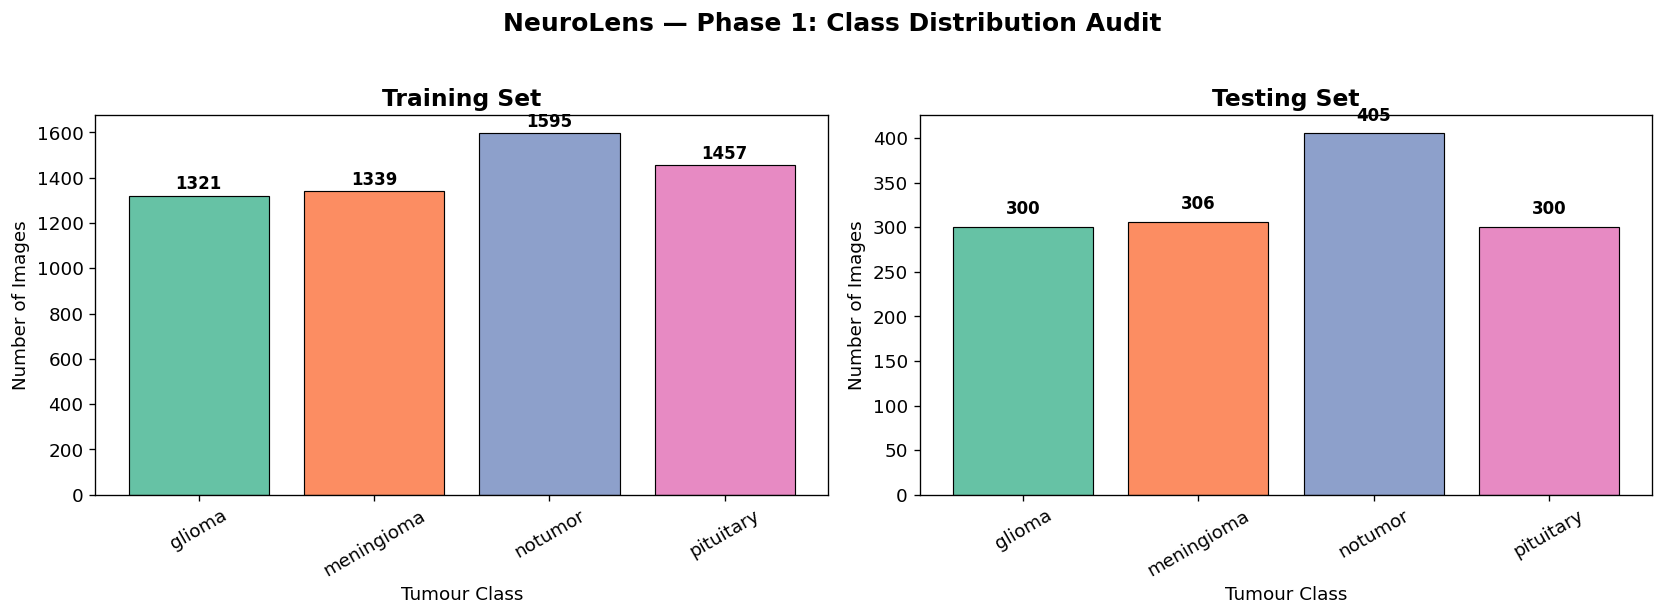

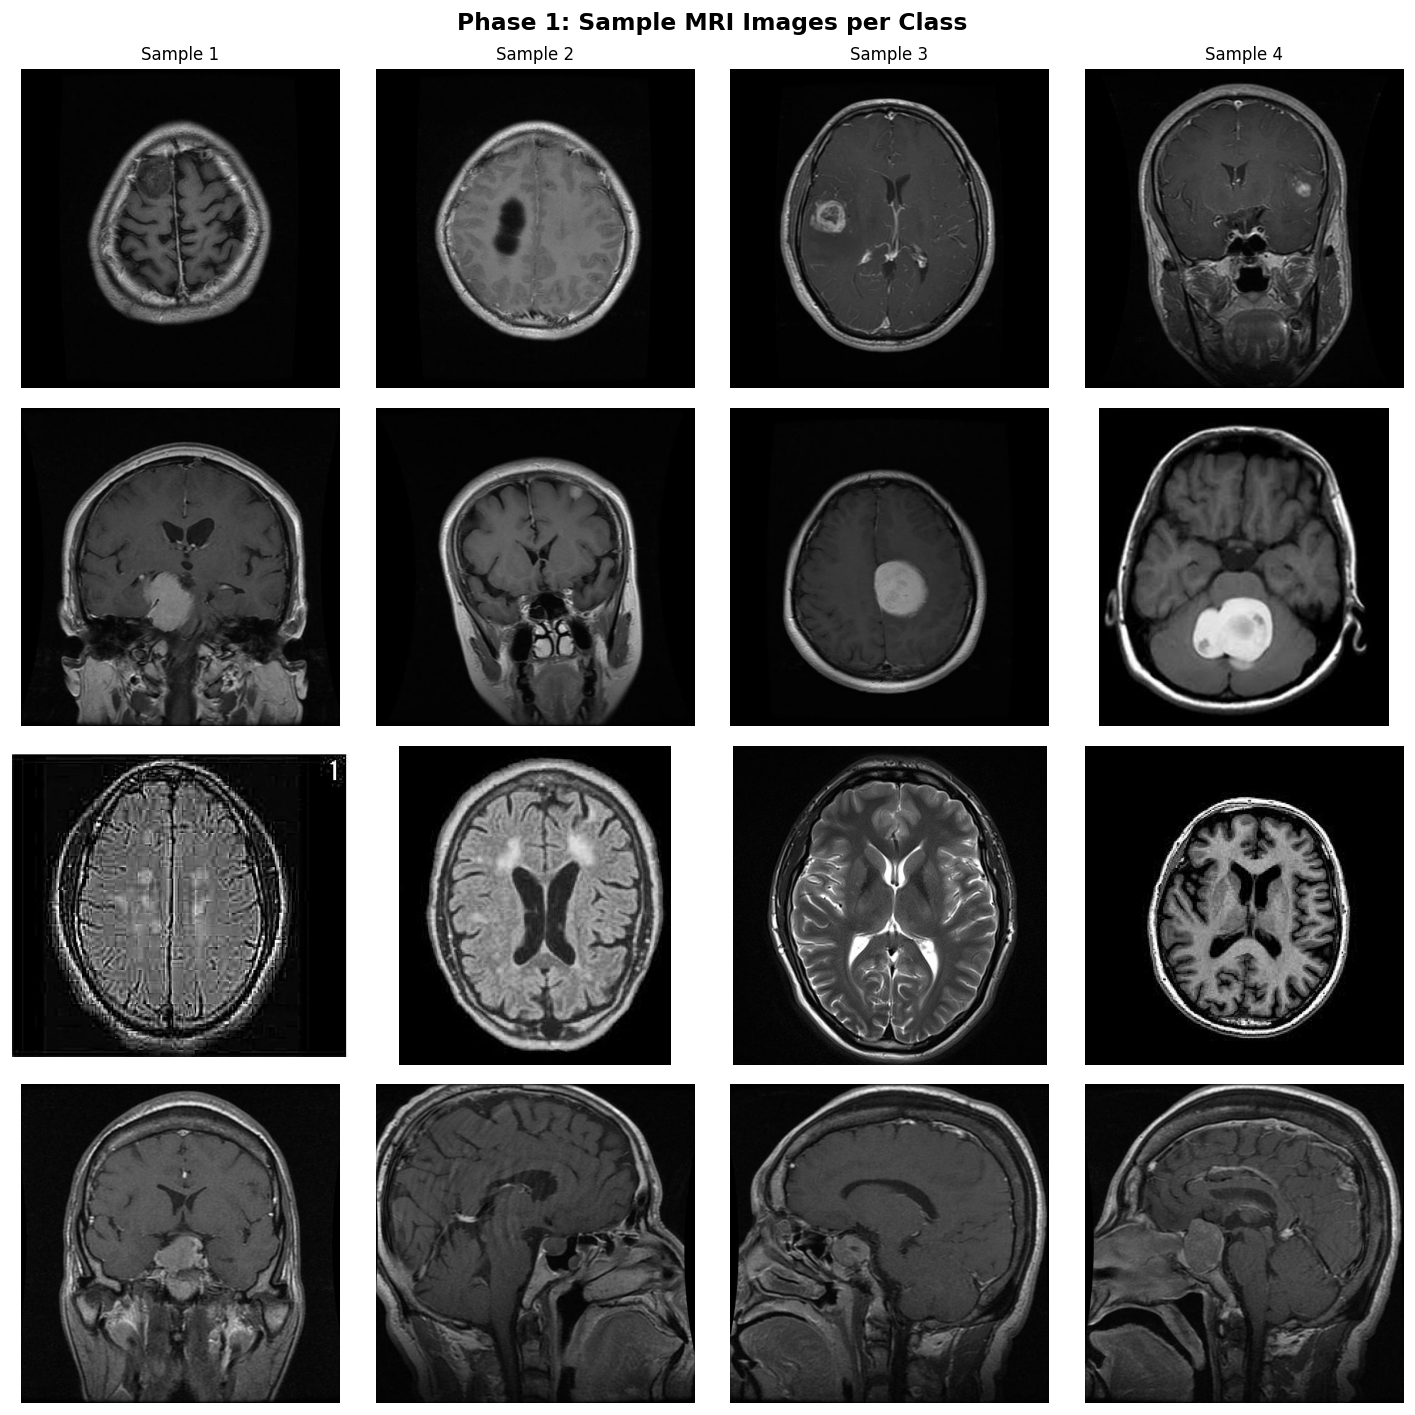

In [5]:
train_counts_dict = {class_names[k]: v
                     for k, v in Counter(raw_train_ds.targets).items()}
test_counts_dict  = {class_names[k]: v
                     for k, v in Counter(raw_test_ds.targets).items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette   = sns.color_palette("Set2", num_classes)

for ax, (counts, title) in zip(axes,
    [(train_counts_dict, "Training Set"),
     (test_counts_dict,  "Testing Set")]):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=palette, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Tumour Class"); ax.set_ylabel("Number of Images")
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 10, str(val),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle("NeuroLens — Phase 1: Class Distribution Audit",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("phase1_class_distribution.png", bbox_inches='tight')
plt.show()

def show_sample_grid(dataset, class_names, n_per_class=4):
    idx_by_class = defaultdict(list)
    for i, (_, label) in enumerate(dataset.samples):
        idx_by_class[label].append(i)

    fig, axes = plt.subplots(len(class_names), n_per_class,
                             figsize=(n_per_class * 3, len(class_names) * 3))
    for row, (cls_idx, cls_name) in enumerate(zip(idx_by_class, class_names)):
        chosen = random.sample(idx_by_class[cls_idx],
                               min(n_per_class, len(idx_by_class[cls_idx])))
        for col, img_idx in enumerate(chosen):
            img = Image.open(dataset.samples[img_idx][0]).convert("RGB")
            axes[row][col].imshow(img); axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_ylabel(cls_name, fontsize=11,
                                          fontweight='bold', rotation=90, labelpad=10)
            if row == 0:
                axes[row][col].set_title(f"Sample {col+1}", fontsize=10)

    plt.suptitle("Phase 1: Sample MRI Images per Class",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("phase1_sample_images.png", bbox_inches='tight')
    plt.show()

show_sample_grid(raw_train_ds, class_names)


---
##  Transforms & DataLoaders (Shared Across All Phases)


In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

set_seed(SEED)
base_ds = datasets.ImageFolder(TRAIN_PATH)
indices = np.arange(len(base_ds))
labels  = np.array(base_ds.targets)
train_idx, val_idx = train_test_split(
    indices, test_size=VAL_SPLIT, random_state=SEED,
    stratify=labels, shuffle=True)

train_base = datasets.ImageFolder(TRAIN_PATH, transform=train_transforms)
val_base   = datasets.ImageFolder(TRAIN_PATH, transform=test_transforms)
test_ds    = datasets.ImageFolder(TEST_PATH,  transform=test_transforms)

train_subset = Subset(train_base, train_idx.tolist())
val_subset   = Subset(val_base,   val_idx.tolist())

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                 pin_memory=torch.cuda.is_available())
train_loader = DataLoader(train_subset, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_subset,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,      shuffle=False, **loader_kw)

print(f" DataLoaders ready")
print(f"   Train : {len(train_subset):5d} images")
print(f"   Val   : {len(val_subset):5d} images")
print(f"   Test  : {len(test_ds):5d} images")


 DataLoaders ready
   Train :  4855 images
   Val   :   857 images
   Test  :  1311 images


---
##  Model Definitions (All Architectures)


In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                  nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        if pool: layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class CustomCNN(nn.Module):
    """Baseline Custom CNN for brain-tumour classification."""
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),
            ConvBlock(32,  64,  pool=True),
            ConvBlock(64,  128, pool=True),
            ConvBlock(128, 256, pool=False),
            ConvBlock(256, 256, pool=True),
            nn.Dropout2d(0.3),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(0.35),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

def build_resnet50(num_classes):
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    for p in model.parameters(): p.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.BatchNorm1d(256), nn.ReLU(inplace=True),
        nn.Dropout(0.35), nn.Linear(256, num_classes))
    return model

def unfreeze_resnet50(model):
    for p in model.layer4.parameters(): p.requires_grad = True
    for p in model.fc.parameters(): p.requires_grad = True

def build_efficientnet_b0(num_classes):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    for p in model.parameters(): p.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Dropout(0.35), nn.Linear(model.classifier[1].in_features, num_classes))
    return model

def unfreeze_efficientnet_b0(model):
    for p in model.features[-2:].parameters(): p.requires_grad = True
    for p in model.classifier.parameters(): p.requires_grad = True

def build_mobilenet_v3_small(num_classes):
    model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
    for p in model.parameters(): p.requires_grad = False
    in_f = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_f, num_classes)
    for p in model.classifier.parameters(): p.requires_grad = True
    return model

def unfreeze_mobilenet(model):
    for p in model.features[-3:].parameters(): p.requires_grad = True
    for p in model.classifier.parameters(): p.requires_grad = True

def count_parameters(model):
    total  = sum(p.numel() for p in model.parameters())
    train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb = total * 4 / 1024**2
    return total, train, size_mb

print(" All model architectures defined.")


 All model architectures defined.


---
##  Training Infrastructure


In [8]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.counter, self.best_loss, self.stop = 0, float('inf'), False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss; self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience: self.stop = True
        return self.stop

def train_model(model, train_loader, val_loader, criterion,
                optimizer, scheduler, num_epochs,
                model_name="Model", patience=PATIENCE):
    model = model.to(device)
    es    = EarlyStopping(patience=patience)
    best_val_acc, best_weights = 0.0, copy.deepcopy(model.state_dict())
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    start_time = time.time()
    print(f"\n{'='*65}")
    print(f"  Training : {model_name}")
    print(f"{'='*65}")

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = correct = total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward(); optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            preds    = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
        train_loss = running_loss / total
        train_acc  = correct / total * 100

        model.eval()
        vl = vc = vt = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                vl  += criterion(out, labels).item() * imgs.size(0)
                vc  += (out.argmax(1) == labels).sum().item()
                vt  += labels.size(0)
        val_loss = vl / vt; val_acc = vc / vt * 100
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        tag = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            tag = "   best"

        print(f"  [{epoch:2d}/{num_epochs}] "
              f"TrL={train_loss:.4f} TrA={train_acc:.1f}% | "
              f"VaL={val_loss:.4f} VaA={val_acc:.1f}% "
              f"LR={optimizer.param_groups[0]['lr']:.1e}{tag}")

        if es(val_loss):
            print(f"    Early stop at epoch {epoch}")
            break

    training_time = time.time() - start_time
    model.load_state_dict(best_weights)
    history["training_time"] = training_time
    print(f"\n   Best Val Acc : {best_val_acc:.2f}%  |  Time: {training_time:.0f}s")
    return model, history

def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, history["train_loss"], 'b-o', ms=4, label='Train')
    axes[0].plot(epochs, history["val_loss"],   'r-o', ms=4, label='Val')
    axes[0].set(title=f"{model_name} – Loss", xlabel="Epoch", ylabel="Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, history["train_acc"], 'b-o', ms=4, label='Train')
    axes[1].plot(epochs, history["val_acc"],   'r-o', ms=4, label='Val')
    axes[1].set(title=f"{model_name} – Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    safe = model_name.replace(" ", "_").lower()
    plt.savefig(f"history_{safe}.png", bbox_inches='tight')
    plt.show()

print(" Training infrastructure ready.")


 Training infrastructure ready.


In [9]:
def evaluate_model(model, loader, class_names, model_name="Model"):
    """Returns metrics dict, y_true, y_pred, y_prob."""
    model.eval(); model.to(device)
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            probs = torch.softmax(model(imgs), dim=1)
            all_labels.extend(labels.numpy())
            all_preds.extend(probs.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    n_cls  = len(class_names)

    acc  = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100

    if n_cls == 2:
        auc_val = roc_auc_score(y_true, y_prob[:, 1]) * 100
    else:
        auc_val = roc_auc_score(
            label_binarize(y_true, classes=list(range(n_cls))),
            y_prob, multi_class='ovr', average='weighted') * 100

    metrics = {"Model": model_name, "Accuracy": acc, "Precision": prec,
               "Recall": rec, "F1": f1, "AUC": auc_val}

    print(f"\n {model_name} — Test Results")
    for k, v in metrics.items():
        if k != "Model": print(f"   {k:12s}: {v:.2f}%")
    print("\n" + classification_report(y_true, y_pred, target_names=class_names))

    return metrics, y_true, y_pred, y_prob

def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set(title=f"{title}\nCounts", xlabel="Predicted", ylabel="True")
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set(title=f"{title}\n(%)", xlabel="Predicted", ylabel="True")
    plt.tight_layout()
    plt.savefig(f"cm_{title.replace(' ','_').lower()}.png", bbox_inches='tight')
    plt.show()

print(" Evaluation utilities ready.")


 Evaluation utilities ready.


---
##  PHASE 2 — BASELINE EXPERIMENT

**Objective:** Train and evaluate the Custom CNN baseline; record all metrics without modification.  
**Research paper sections:** Baseline Results, Experimental Setup


 Custom CNN Parameters  : 1,046,564
   Trainable             : 1,046,564
   Estimated size        : 3.99 MB

  Training : Custom CNN (Baseline)
  [ 1/30] TrL=0.9727 TrA=63.8% | VaL=0.8671 VaA=62.2% LR=3.0e-04   best
  [ 2/30] TrL=0.7876 TrA=73.5% | VaL=0.6433 VaA=78.3% LR=3.0e-04   best
  [ 3/30] TrL=0.7008 TrA=77.7% | VaL=0.8136 VaA=71.8% LR=3.0e-04
  [ 4/30] TrL=0.6381 TrA=81.2% | VaL=0.5131 VaA=88.7% LR=3.0e-04   best
  [ 5/30] TrL=0.6247 TrA=83.1% | VaL=0.5736 VaA=85.6% LR=3.0e-04
  [ 6/30] TrL=0.5981 TrA=83.9% | VaL=0.4831 VaA=87.6% LR=3.0e-04
  [ 7/30] TrL=0.5737 TrA=85.2% | VaL=0.4921 VaA=87.7% LR=3.0e-04
  [ 8/30] TrL=0.5505 TrA=85.6% | VaL=0.6055 VaA=81.7% LR=3.0e-04
  [ 9/30] TrL=0.5347 TrA=86.3% | VaL=0.6360 VaA=79.5% LR=1.5e-04
  [10/30] TrL=0.4985 TrA=88.0% | VaL=0.4442 VaA=89.5% LR=1.5e-04   best
  [11/30] TrL=0.4976 TrA=88.3% | VaL=0.4045 VaA=91.1% LR=1.5e-04   best
  [12/30] TrL=0.4819 TrA=88.9% | VaL=0.3924 VaA=91.5% LR=1.5e-04   best
  [13/30] TrL=0.4811 TrA=89.5% | V

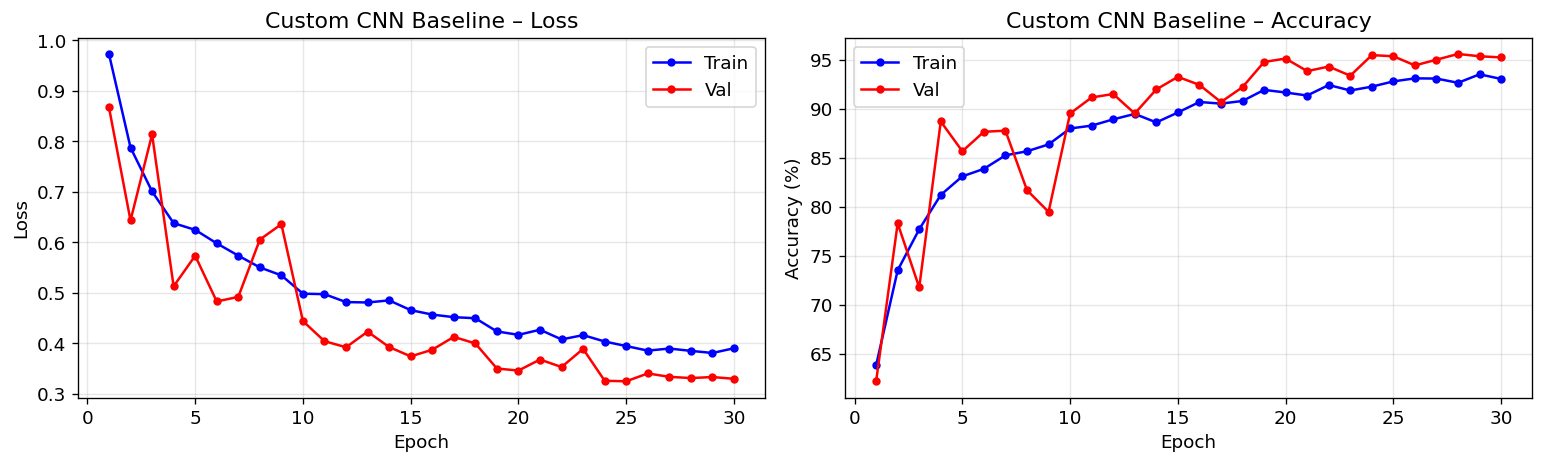


 Baseline model saved → 'neurolens_baseline.pth'


In [10]:
set_seed(SEED)
baseline_model = CustomCNN(num_classes)

total_p, train_p, size_mb = count_parameters(baseline_model)
print(f" Custom CNN Parameters  : {total_p:,}")
print(f"   Trainable             : {train_p:,}")
print(f"   Estimated size        : {size_mb:.2f} MB")

crit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
opt  = optim.AdamW(baseline_model.parameters(), lr=3e-4, weight_decay=WEIGHT_DECAY)
sch  = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)

baseline_model, baseline_history = train_model(
    baseline_model, train_loader, val_loader,
    crit, opt, sch, NUM_EPOCHS,
    model_name="Custom CNN (Baseline)", patience=PATIENCE)

plot_history(baseline_history, "Custom CNN Baseline")
torch.save(baseline_model.state_dict(), MODEL_SAVE)
print(f"\n Baseline model saved → '{MODEL_SAVE}'")



 Custom CNN (Baseline) — Test Results
   Accuracy    : 92.52%
   Precision   : 92.58%
   Recall      : 92.52%
   F1          : 92.46%
   AUC         : 99.08%

              precision    recall  f1-score   support

      glioma       0.97      0.90      0.93       300
  meningioma       0.85      0.82      0.84       306
     notumor       0.91      0.99      0.95       405
   pituitary       0.97      0.97      0.97       300

    accuracy                           0.93      1311
   macro avg       0.93      0.92      0.92      1311
weighted avg       0.93      0.93      0.92      1311



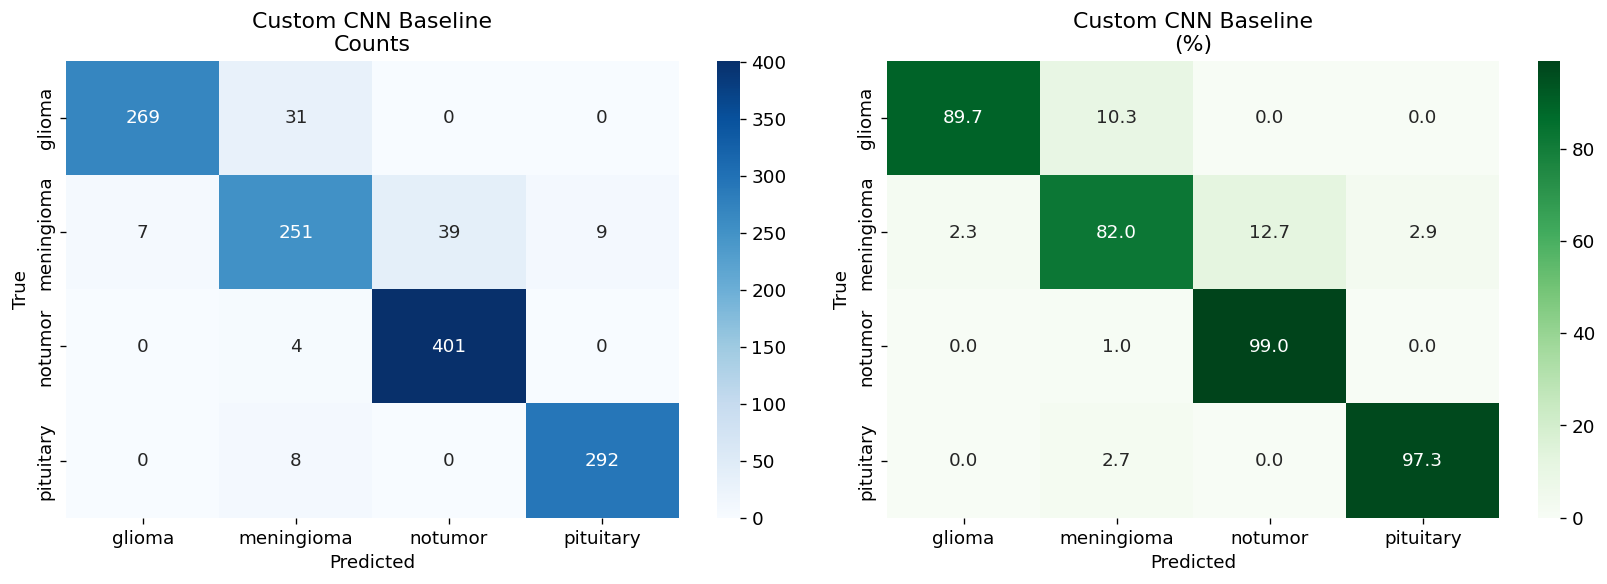


 PHASE 2 BASELINE SUMMARY
   Accuracy                 : 92.52479023646072
   Precision                : 92.58340010423403
   Recall                   : 92.52479023646072
   F1                       : 92.45865819775392
   AUC                      : 99.08107744948673
   Training Time (s)        : 726.9487941265106
   CPU Inf (ms)             : 45.69
   GPU Inf (ms)             : 1.38
   Parameters               : 1046564
   Size (MB)                : 3.99


In [11]:
baseline_metrics, bl_yt, bl_yp, bl_yprob = evaluate_model(
    baseline_model, test_loader, class_names, "Custom CNN (Baseline)")

plot_confusion_matrix(bl_yt, bl_yp, class_names, "Custom CNN Baseline")

baseline_model.eval(); baseline_model.to(device)
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
for _ in range(10): _ = baseline_model(dummy)
dummy_cpu = dummy.cpu()
baseline_model_cpu = baseline_model.cpu()
t0 = time.time()
for _ in range(100): baseline_model_cpu(dummy_cpu)
cpu_inf = (time.time() - t0) / 100 * 1000
baseline_model.to(device)

gpu_inf = None
if torch.cuda.is_available():
    t0 = time.time()
    for _ in range(100):
        with torch.no_grad(): baseline_model(dummy)
    torch.cuda.synchronize()
    gpu_inf = (time.time() - t0) / 100 * 1000

baseline_metrics["Training Time (s)"] = baseline_history.get("training_time", 0)
baseline_metrics["CPU Inf (ms)"]      = round(cpu_inf, 2)
baseline_metrics["GPU Inf (ms)"]      = round(gpu_inf, 2) if gpu_inf else "N/A"
baseline_metrics["Parameters"]        = count_parameters(baseline_model)[0]
baseline_metrics["Size (MB)"]         = round(count_parameters(baseline_model)[2], 2)

print("\n PHASE 2 BASELINE SUMMARY")
print("=" * 50)
for k, v in baseline_metrics.items():
    if k != "Model":
        print(f"   {k:25s}: {v}")


---
##  PHASE 3 — LIGHTWEIGHT MODEL COMPARISON

**Objective:** Compare baseline with MobileNetV3-Small, EfficientNet-B0, ResNet50.  
**Research paper sections:** Model Comparison, Lightweight Analysis



  Training : ResNet50 (Head)
  [ 1/8] TrL=0.5677 TrA=87.1% | VaL=0.4939 VaA=89.6% LR=1.0e-03   best
  [ 2/8] TrL=0.4615 TrA=91.0% | VaL=0.4543 VaA=89.3% LR=1.0e-03
  [ 3/8] TrL=0.4455 TrA=91.4% | VaL=0.4494 VaA=89.5% LR=1.0e-03
  [ 4/8] TrL=0.4397 TrA=91.4% | VaL=0.4607 VaA=91.8% LR=1.0e-03   best
  [ 5/8] TrL=0.4178 TrA=92.5% | VaL=0.4504 VaA=90.9% LR=1.0e-03
  [ 6/8] TrL=0.4165 TrA=92.2% | VaL=0.4280 VaA=91.1% LR=1.0e-03
  [ 7/8] TrL=0.4217 TrA=92.4% | VaL=0.4595 VaA=90.0% LR=1.0e-03
  [ 8/8] TrL=0.4027 TrA=93.0% | VaL=0.4326 VaA=92.1% LR=1.0e-03   best

   Best Val Acc : 92.07%  |  Time: 288s

  Training : ResNet50 (FT)
  [ 1/22] TrL=0.3854 TrA=93.9% | VaL=0.4510 VaA=92.8% LR=1.0e-05   best
  [ 2/22] TrL=0.3661 TrA=94.3% | VaL=0.4144 VaA=93.3% LR=1.0e-05   best
  [ 3/22] TrL=0.3628 TrA=94.8% | VaL=0.4566 VaA=94.3% LR=1.0e-05   best
  [ 4/22] TrL=0.3537 TrA=95.0% | VaL=0.4044 VaA=93.6% LR=1.0e-05
  [ 5/22] TrL=0.3446 TrA=95.7% | VaL=0.3833 VaA=94.5% LR=1.0e-05   best
  [ 6/22] TrL=0

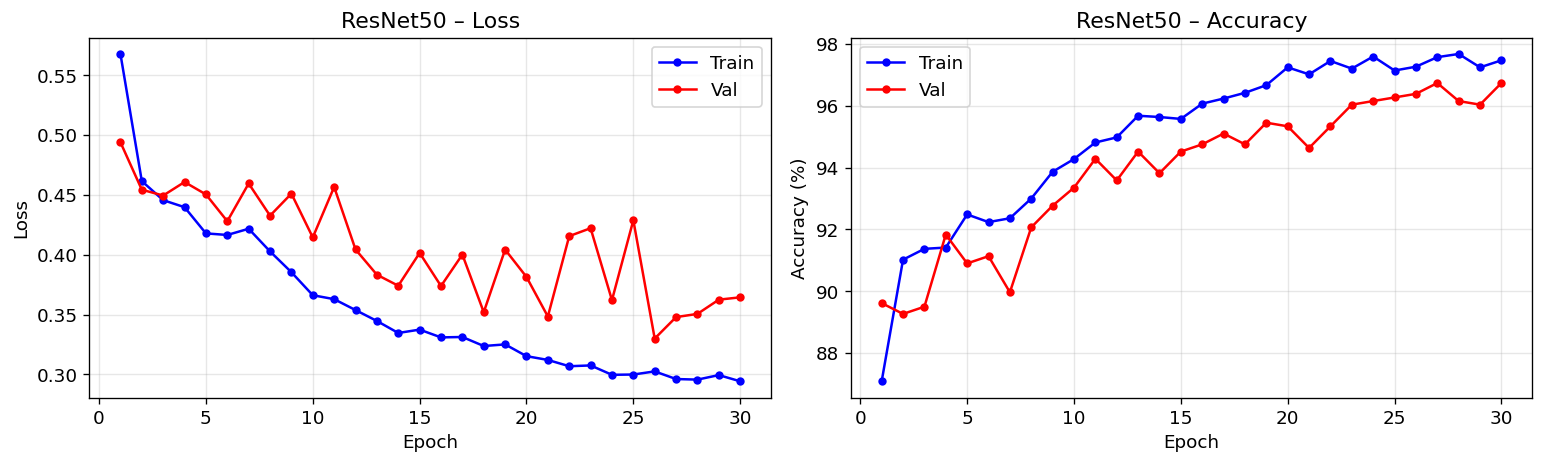

In [12]:
set_seed(SEED)
r50 = build_resnet50(num_classes)
crit_r50 = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
opt_r50  = optim.AdamW(filter(lambda p: p.requires_grad, r50.parameters()),
                        lr=1e-3, weight_decay=WEIGHT_DECAY)
sch_r50  = optim.lr_scheduler.ReduceLROnPlateau(opt_r50, 'min', factor=0.5, patience=2)
r50, r50_h1 = train_model(r50, train_loader, val_loader, crit_r50,
                            opt_r50, sch_r50, HEAD_EPOCHS, "ResNet50 (Head)", 4)

unfreeze_resnet50(r50)
opt_r50 = optim.AdamW(filter(lambda p: p.requires_grad, r50.parameters()),
                       lr=1e-5, weight_decay=WEIGHT_DECAY)
sch_r50 = optim.lr_scheduler.ReduceLROnPlateau(opt_r50, 'min', factor=0.5, patience=2)
r50, r50_h2 = train_model(r50, train_loader, val_loader, crit_r50,
                            opt_r50, sch_r50, FINETUNE_EPOCHS, "ResNet50 (FT)", PATIENCE)
r50_history = {k: r50_h1[k] + r50_h2[k] for k in r50_h1 if isinstance(r50_h1[k], list)}
r50_history["training_time"] = r50_h1.get("training_time",0) + r50_h2.get("training_time",0)
plot_history(r50_history, "ResNet50")



  Training : EfficientNet-B0 (Head)
  [ 1/8] TrL=0.7523 TrA=78.5% | VaL=0.5503 VaA=87.0% LR=1.0e-03   best
  [ 2/8] TrL=0.5594 TrA=85.3% | VaL=0.4871 VaA=88.6% LR=1.0e-03   best
  [ 3/8] TrL=0.5322 TrA=87.4% | VaL=0.4707 VaA=88.6% LR=1.0e-03
  [ 4/8] TrL=0.5189 TrA=87.0% | VaL=0.4532 VaA=89.1% LR=1.0e-03   best
  [ 5/8] TrL=0.4950 TrA=88.3% | VaL=0.4429 VaA=90.3% LR=1.0e-03   best
  [ 6/8] TrL=0.5001 TrA=87.8% | VaL=0.4413 VaA=90.4% LR=1.0e-03   best
  [ 7/8] TrL=0.4995 TrA=87.9% | VaL=0.4396 VaA=90.3% LR=1.0e-03
  [ 8/8] TrL=0.4944 TrA=88.7% | VaL=0.4216 VaA=90.8% LR=1.0e-03   best

   Best Val Acc : 90.78%  |  Time: 191s

  Training : EfficientNet-B0 (FT)
  [ 1/22] TrL=0.4865 TrA=88.5% | VaL=0.4224 VaA=90.9% LR=1.0e-05   best
  [ 2/22] TrL=0.4808 TrA=89.2% | VaL=0.4117 VaA=91.7% LR=1.0e-05   best
  [ 3/22] TrL=0.4679 TrA=89.4% | VaL=0.4102 VaA=91.2% LR=1.0e-05
  [ 4/22] TrL=0.4639 TrA=89.8% | VaL=0.4020 VaA=91.7% LR=1.0e-05
  [ 5/22] TrL=0.4550 TrA=90.0% | VaL=0.4010 VaA=91.2% LR=1.

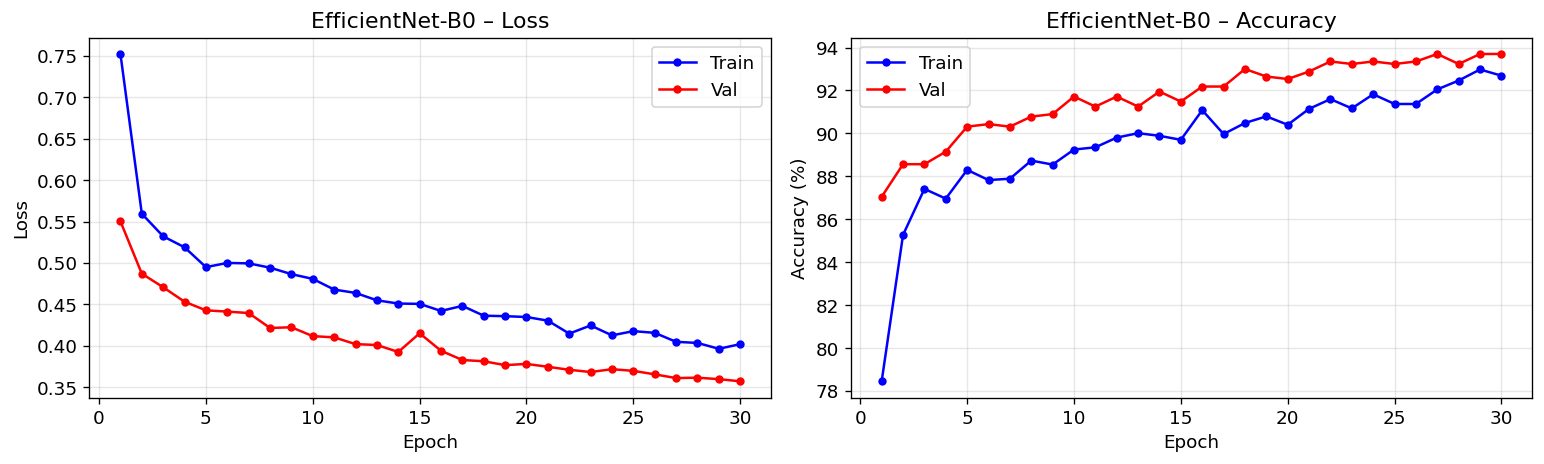

In [13]:
set_seed(SEED)
eff = build_efficientnet_b0(num_classes)
crit_eff = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
opt_eff  = optim.AdamW(filter(lambda p: p.requires_grad, eff.parameters()),
                        lr=1e-3, weight_decay=WEIGHT_DECAY)
sch_eff  = optim.lr_scheduler.ReduceLROnPlateau(opt_eff, 'min', factor=0.5, patience=2)
eff, eff_h1 = train_model(eff, train_loader, val_loader, crit_eff,
                            opt_eff, sch_eff, HEAD_EPOCHS, "EfficientNet-B0 (Head)", 4)

unfreeze_efficientnet_b0(eff)
opt_eff = optim.AdamW(filter(lambda p: p.requires_grad, eff.parameters()),
                       lr=1e-5, weight_decay=WEIGHT_DECAY)
sch_eff = optim.lr_scheduler.ReduceLROnPlateau(opt_eff, 'min', factor=0.5, patience=2)
eff, eff_h2 = train_model(eff, train_loader, val_loader, crit_eff,
                            opt_eff, sch_eff, FINETUNE_EPOCHS, "EfficientNet-B0 (FT)", PATIENCE)
eff_history = {k: eff_h1[k] + eff_h2[k] for k in eff_h1 if isinstance(eff_h1[k], list)}
eff_history["training_time"] = eff_h1.get("training_time",0) + eff_h2.get("training_time",0)
plot_history(eff_history, "EfficientNet-B0")



  Training : MobileNetV3-S (Head)
  [ 1/8] TrL=0.6375 TrA=82.9% | VaL=0.8388 VaA=70.4% LR=1.0e-03   best
  [ 2/8] TrL=0.5150 TrA=88.2% | VaL=0.6679 VaA=78.9% LR=1.0e-03   best
  [ 3/8] TrL=0.4826 TrA=89.3% | VaL=0.4596 VaA=89.3% LR=1.0e-03   best
  [ 4/8] TrL=0.4660 TrA=89.8% | VaL=0.5001 VaA=88.6% LR=1.0e-03
  [ 5/8] TrL=0.4533 TrA=90.4% | VaL=0.4556 VaA=89.8% LR=1.0e-03   best
  [ 6/8] TrL=0.4313 TrA=91.6% | VaL=0.4554 VaA=90.3% LR=1.0e-03   best
  [ 7/8] TrL=0.4236 TrA=92.1% | VaL=0.4127 VaA=91.4% LR=1.0e-03   best
  [ 8/8] TrL=0.4011 TrA=93.2% | VaL=0.4109 VaA=90.8% LR=1.0e-03

   Best Val Acc : 91.37%  |  Time: 174s

  Training : MobileNetV3-S (FT)
  [ 1/22] TrL=0.3936 TrA=92.6% | VaL=0.3947 VaA=92.6% LR=1.0e-05   best
  [ 2/22] TrL=0.3747 TrA=93.5% | VaL=0.3927 VaA=92.8% LR=1.0e-05   best
  [ 3/22] TrL=0.3713 TrA=93.5% | VaL=0.3875 VaA=93.0% LR=1.0e-05   best
  [ 4/22] TrL=0.3629 TrA=94.0% | VaL=0.3855 VaA=92.9% LR=1.0e-05
  [ 5/22] TrL=0.3650 TrA=93.9% | VaL=0.3811 VaA=93.1% LR

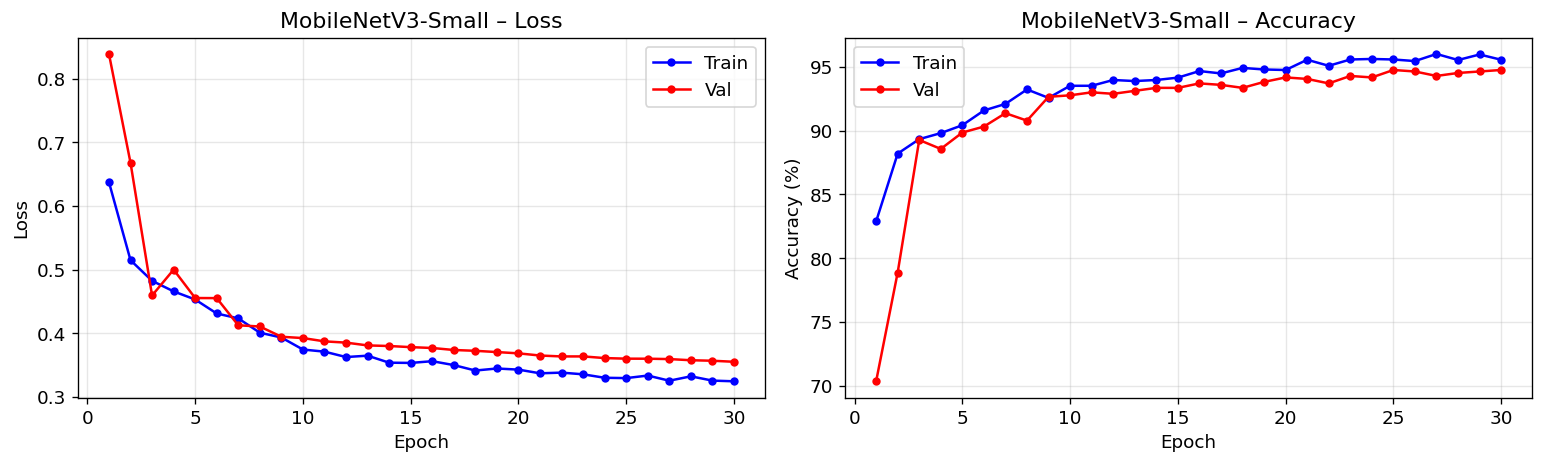

In [14]:
set_seed(SEED)
mob = build_mobilenet_v3_small(num_classes)
crit_mob = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
opt_mob  = optim.AdamW(filter(lambda p: p.requires_grad, mob.parameters()),
                        lr=1e-3, weight_decay=WEIGHT_DECAY)
sch_mob  = optim.lr_scheduler.ReduceLROnPlateau(opt_mob, 'min', factor=0.5, patience=2)
mob, mob_h1 = train_model(mob, train_loader, val_loader, crit_mob,
                            opt_mob, sch_mob, HEAD_EPOCHS, "MobileNetV3-S (Head)", 4)

unfreeze_mobilenet(mob)
opt_mob = optim.AdamW(filter(lambda p: p.requires_grad, mob.parameters()),
                       lr=1e-5, weight_decay=WEIGHT_DECAY)
sch_mob = optim.lr_scheduler.ReduceLROnPlateau(opt_mob, 'min', factor=0.5, patience=2)
mob, mob_h2 = train_model(mob, train_loader, val_loader, crit_mob,
                            opt_mob, sch_mob, FINETUNE_EPOCHS, "MobileNetV3-S (FT)", PATIENCE)
mob_history = {k: mob_h1[k] + mob_h2[k] for k in mob_h1 if isinstance(mob_h1[k], list)}
mob_history["training_time"] = mob_h1.get("training_time",0) + mob_h2.get("training_time",0)
plot_history(mob_history, "MobileNetV3-Small")


In [15]:
def get_inference_time(model, device_name='cpu'):
    m = model.cpu() if device_name == 'cpu' else model.to(device)
    d = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    d = d if device_name == 'cpu' else d.to(device)
    for _ in range(10): m(d)
    t0 = time.time()
    for _ in range(100):
        with torch.no_grad(): m(d)
    if device_name == 'gpu' and torch.cuda.is_available():
        torch.cuda.synchronize()
    return round((time.time() - t0) / 100 * 1000, 3)

all_model_results = []
model_registry = {
    "Custom CNN":       (baseline_model, baseline_history),
    "ResNet50":         (r50,            r50_history),
    "EfficientNet-B0":  (eff,            eff_history),
    "MobileNetV3-Small":(mob,            mob_history),
}

for name, (m, hist) in model_registry.items():
    met, yt, yp, yprob = evaluate_model(m, test_loader, class_names, name)
    tot, tr, sz = count_parameters(m)
    met["Params (M)"]   = round(tot / 1e6, 2)
    met["Size (MB)"]    = round(sz, 2)
    met["Train Time (s)"]= round(hist.get("training_time", 0))
    met["CPU Inf (ms)"] = get_inference_time(m, 'cpu')
    met["GPU Inf (ms)"] = get_inference_time(m, 'gpu') if torch.cuda.is_available() else "N/A"
    all_model_results.append(met)
    m.to(device)

results_df = pd.DataFrame(all_model_results).set_index("Model")
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC",
               "Params (M)", "Size (MB)", "Train Time (s)", "CPU Inf (ms)"]

print("\n" + "="*80)
print("    PHASE 3: LIGHTWEIGHT MODEL COMPARISON TABLE")
print("="*80)
print(results_df[metric_cols].to_string())
print("="*80)



 Custom CNN — Test Results
   Accuracy    : 92.52%
   Precision   : 92.58%
   Recall      : 92.52%
   F1          : 92.46%
   AUC         : 99.08%

              precision    recall  f1-score   support

      glioma       0.97      0.90      0.93       300
  meningioma       0.85      0.82      0.84       306
     notumor       0.91      0.99      0.95       405
   pituitary       0.97      0.97      0.97       300

    accuracy                           0.93      1311
   macro avg       0.93      0.92      0.92      1311
weighted avg       0.93      0.93      0.92      1311


 ResNet50 — Test Results
   Accuracy    : 96.26%
   Precision   : 96.28%
   Recall      : 96.26%
   F1          : 96.25%
   AUC         : 99.69%

              precision    recall  f1-score   support

      glioma       0.97      0.92      0.95       300
  meningioma       0.92      0.93      0.93       306
     notumor       0.97      1.00      0.98       405
   pituitary       0.99      0.99      0.99       30

 Best Model : ResNet50
   Accuracy  : 96.26%
   F1        : 96.25%
   AUC       : 99.69%
   Composite : 97.29%

 Best model saved → 'neurolens_best.pth'


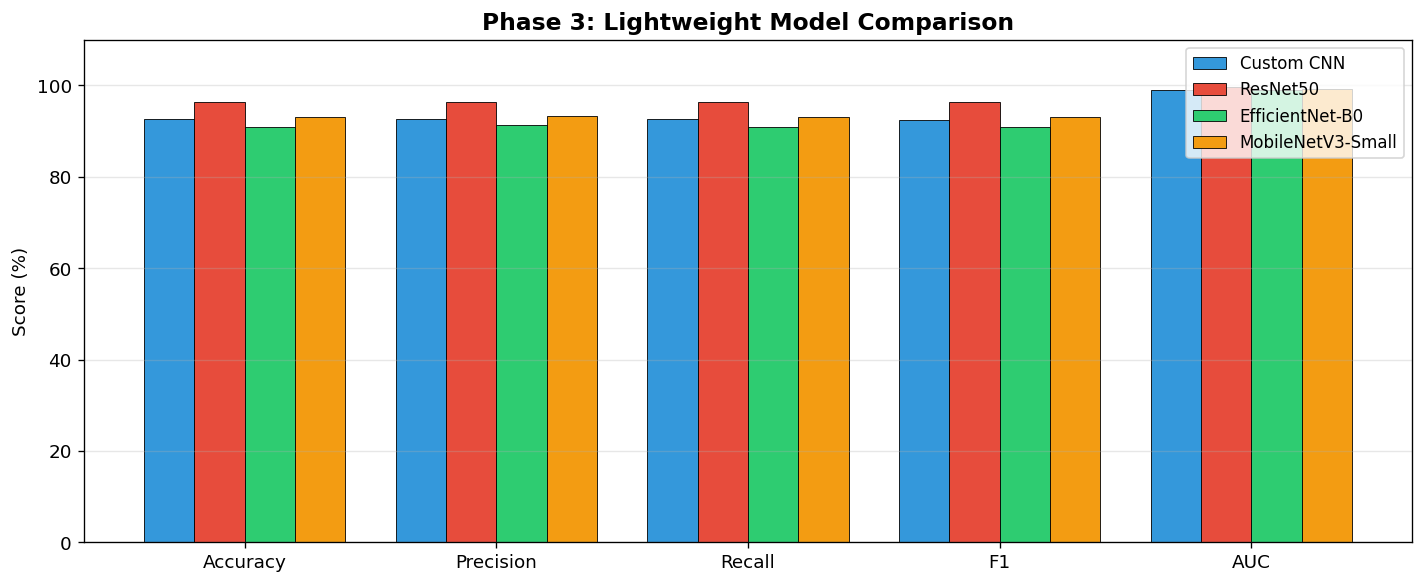

In [16]:
results_df["Composite"] = (results_df["F1"] * 0.40 +
                            results_df["AUC"] * 0.30 +
                            results_df["Accuracy"] * 0.30)
best_model_name = results_df["Composite"].idxmax()
best_model      = model_registry[best_model_name][0]

print(f" Best Model : {best_model_name}")
print(f"   Accuracy  : {results_df.loc[best_model_name, 'Accuracy']:.2f}%")
print(f"   F1        : {results_df.loc[best_model_name, 'F1']:.2f}%")
print(f"   AUC       : {results_df.loc[best_model_name, 'AUC']:.2f}%")
print(f"   Composite : {results_df.loc[best_model_name, 'Composite']:.2f}%")

torch.save({
    "model_state_dict": best_model.state_dict(),
    "class_names": class_names,
    "num_classes": num_classes,
    "best_model_name": best_model_name,
    "results": results_df[metric_cols].to_dict(),
}, BEST_MODEL_SAVE)
print(f"\n Best model saved → '{BEST_MODEL_SAVE}'")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(["Accuracy", "Precision", "Recall", "F1", "AUC"]))
w = 0.2
perf_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for i, (name, color) in enumerate(zip(results_df.index, colors)):
    vals = results_df.loc[name, perf_cols].values.astype(float)
    bars = ax.bar(x + i*w, vals, w, label=name, color=color,
                  edgecolor='black', linewidth=0.5)
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(perf_cols, fontsize=11)
ax.set_ylabel("Score (%)"); ax.set_ylim(0, 110)
ax.set_title("Phase 3: Lightweight Model Comparison", fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("phase3_model_comparison.png", bbox_inches='tight')
plt.show()


---
##  PHASE 4 — EXPLAINABLE AI (XAI)

**Objective:** Implement Grad-CAM++ and Integrated Gradients; compute Explanation Agreement Score.  
**Research paper sections:** Explainability Analysis


In [17]:
class GradCAMPlusPlus:
    """
    Grad-CAM++ — improved Grad-CAM with better class-discriminative
    localisation via second-order gradient weights.
    Reference: Chattopadhyay et al. (2018).
    """
    def __init__(self, model, target_layer):
        self.model, self.target_layer = model, target_layer
        self.activations = self.gradients = None
        self._hooks = []
        self._hooks.append(target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach())))
        self._hooks.append(target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach())))

    def generate(self, tensor, class_idx=None):
        self.model.eval()
        tensor = tensor.unsqueeze(0).to(device).requires_grad_(True)
        out    = self.model(tensor)
        if class_idx is None: class_idx = out.argmax(1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(out); one_hot[0, class_idx] = 1.0
        out.backward(gradient=one_hot, retain_graph=True)

        grads  = self.gradients.squeeze(0)  # [C, H, W]
        acts   = self.activations.squeeze(0)

        # Grad-CAM++ alpha weights
        grads_2 = grads ** 2
        grads_3 = grads ** 3
        denom   = 2.0 * grads_2 + (acts * grads_3).sum(dim=(1, 2), keepdim=True)
        denom   = torch.where(denom == 0, torch.ones_like(denom), denom)
        alpha   = grads_2 / denom
        weights = (alpha * F.relu(grads)).sum(dim=(1, 2))  # [C]

        heatmap = (weights[:, None, None] * acts).sum(0)
        heatmap = F.relu(heatmap).cpu().numpy()
        if heatmap.max() > 0: heatmap /= heatmap.max()
        return heatmap

    def remove(self):
        for h in self._hooks: h.remove()

def get_last_conv(model):
    last = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d): last = m
    if last is None: raise ValueError("No Conv2d found in model.")
    return last

print(" Grad-CAM++ class defined.")


 Grad-CAM++ class defined.


In [18]:
class IntegratedGradients:
    """
    Integrated Gradients (Sundararajan et al., 2017).
    Attributes each pixel's contribution by integrating gradients
    along a linear path from a baseline (black image) to the input.
    """
    def __init__(self, model):
        self.model = model

    def generate(self, tensor, class_idx=None, steps=50):
        """Returns an attribution map (H, W) in [0,1]."""
        self.model.eval()
        inp = tensor.unsqueeze(0).to(device)

        # Black baseline
        baseline = torch.zeros_like(inp)

        # Predict class if not given
        with torch.no_grad():
            if class_idx is None:
                class_idx = self.model(inp).argmax(1).item()

        # Interpolate
        alphas    = torch.linspace(0, 1, steps + 1, device=device)
        interps   = baseline + alphas[:, None, None, None] * (inp - baseline)
        interps.requires_grad_(True)

        # Forward + backward
        outs = self.model(interps)
        score = outs[:, class_idx].sum()
        score.backward()

        # Integrated gradients = (inp - baseline) × mean_grad
        grads = interps.grad.detach()                 # [steps+1, C, H, W]
        avg_grads = grads.mean(dim=0)                 # [C, H, W]
        ig = ((inp.detach() - baseline) * avg_grads).squeeze(0)  # [C, H, W]

        # Aggregate channels → spatial map
        attr_map = ig.abs().sum(dim=0).cpu().numpy()  # [H, W]
        if attr_map.max() > 0: attr_map /= attr_map.max()
        return attr_map

print(" Integrated Gradients class defined.")


 Integrated Gradients class defined.


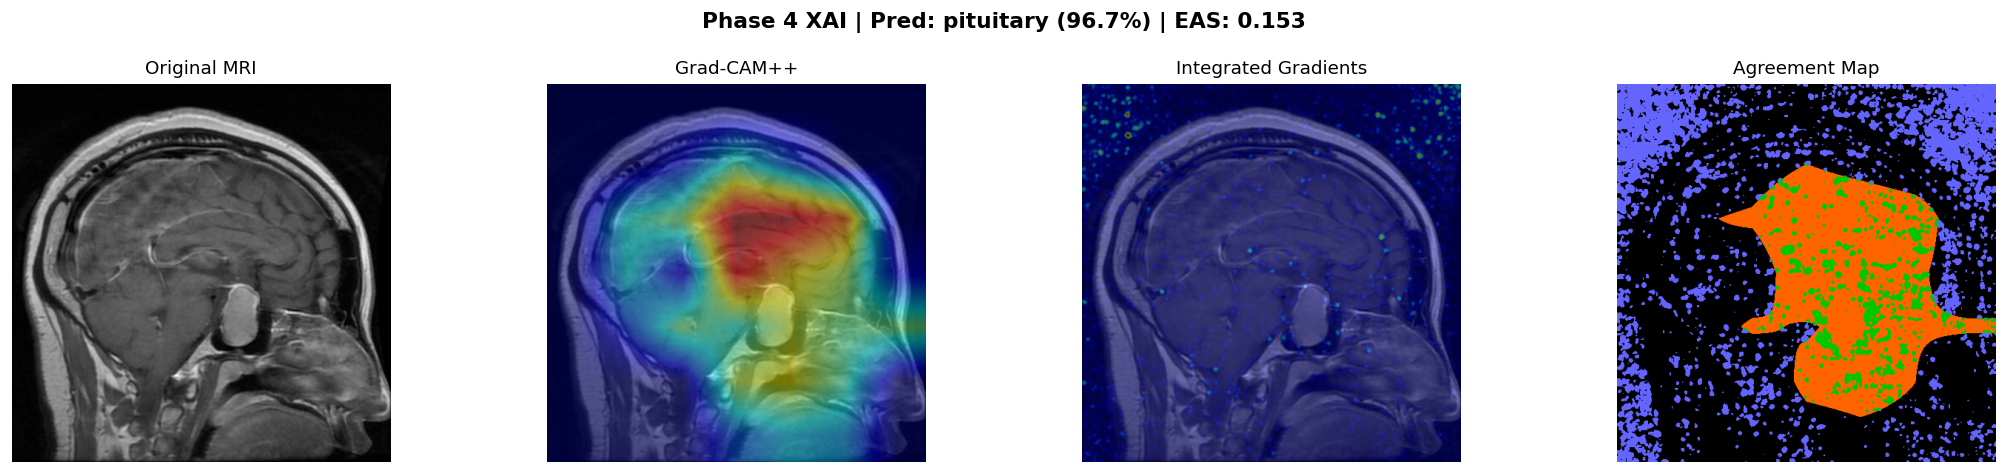


 Predicted : pituitary (96.7%)
   EAS (Explanation Agreement Score) : 0.1529
   Colour key:  Agreement   Grad-CAM++ only   IG only


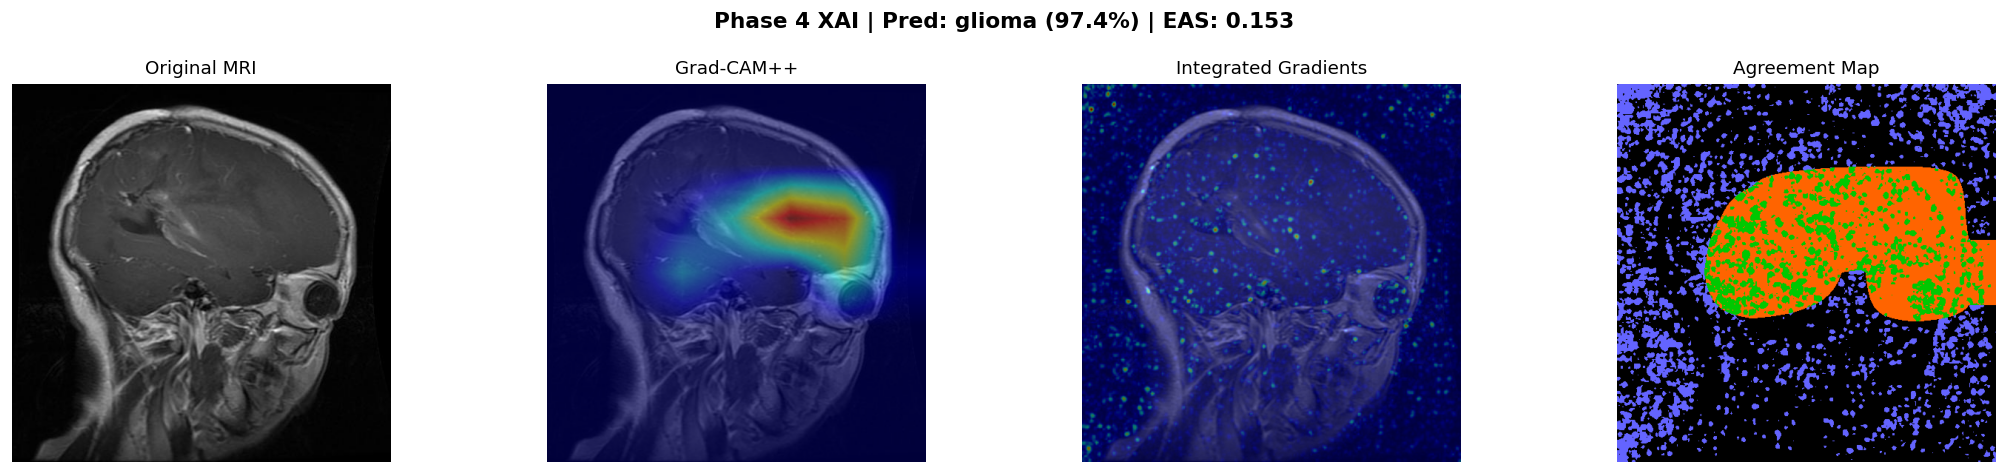


 Predicted : glioma (97.4%)
   EAS (Explanation Agreement Score) : 0.1529
   Colour key:  Agreement   Grad-CAM++ only   IG only


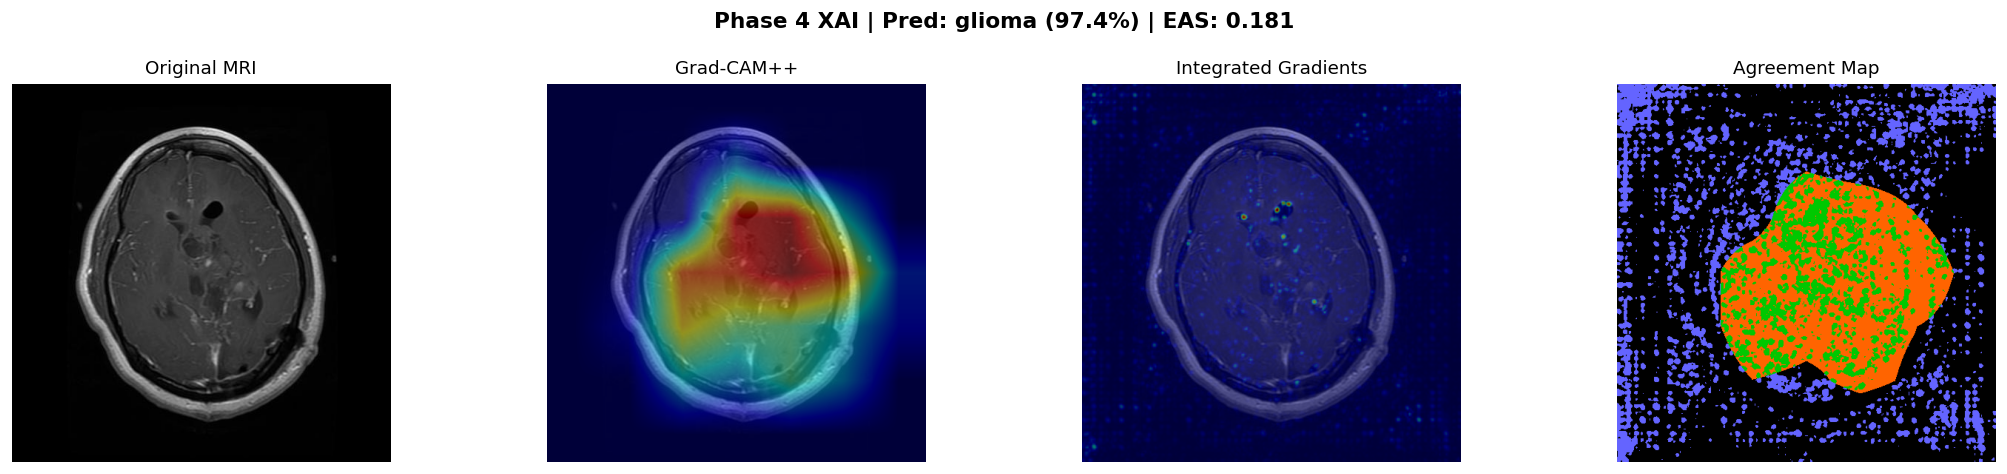


 Predicted : glioma (97.4%)
   EAS (Explanation Agreement Score) : 0.1807
   Colour key:  Agreement   Grad-CAM++ only   IG only


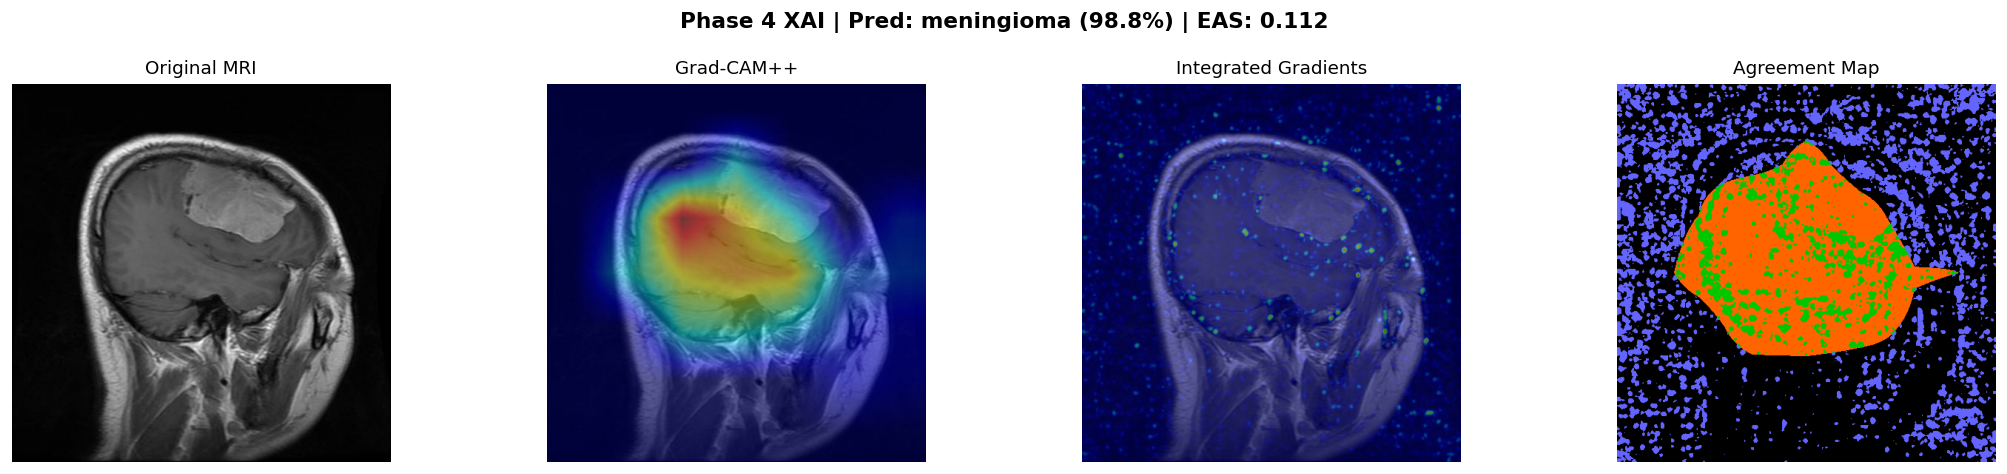


 Predicted : meningioma (98.8%)
   EAS (Explanation Agreement Score) : 0.1124
   Colour key:  Agreement   Grad-CAM++ only   IG only


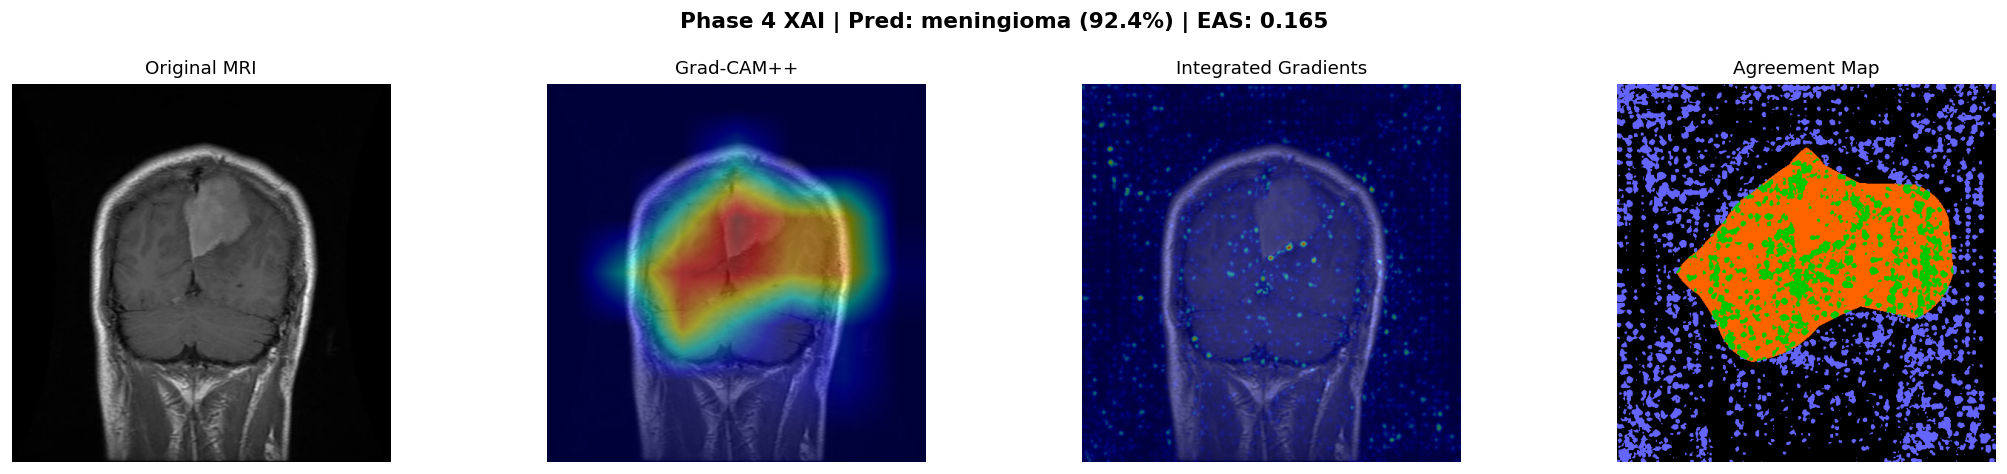


 Predicted : meningioma (92.4%)
   EAS (Explanation Agreement Score) : 0.1647
   Colour key:  Agreement   Grad-CAM++ only   IG only

 Mean EAS over 5 images: 0.1527 ± 0.0226


In [19]:
def explanation_agreement_score(map1: np.ndarray, map2: np.ndarray,
                                 resize_to=(14, 14)) -> float:
    """
    Explanation Agreement Score (EAS) between two XAI saliency maps.

    Method:
    -------
    1. Resize both maps to a common resolution (avoids scale effects).
    2. Flatten and binarise at the 75th-percentile threshold of each map
       (top-25% activated regions → foreground mask).
    3. Compute Intersection-over-Union (IoU) of the two binary masks.

    EAS ∈ [0, 1]:
      1.0  → perfect spatial agreement (both methods highlight the same regions)
      0.0  → no overlap

    Rationale:
    ----------
    Agreement between independently-derived explanation methods
    increases confidence that the highlighted regions are genuinely
    important to the model, rather than artefacts of a single method.
    """
    h, w = resize_to
    m1 = cv2.resize(map1, (w, h))
    m2 = cv2.resize(map2, (w, h))

    # Binarise at 75th-percentile threshold per map
    t1 = np.percentile(m1, 75)
    t2 = np.percentile(m2, 75)
    b1 = (m1 >= t1).astype(np.uint8)
    b2 = (m2 >= t2).astype(np.uint8)

    intersection = (b1 & b2).sum()
    union        = (b1 | b2).sum()
    eas          = intersection / union if union > 0 else 0.0
    return float(eas)

def visualise_xai(model, image_path, class_names, target_class=None):
    """
    Full XAI pipeline for one image:
    original | Grad-CAM++ | Integrated Gradients | overlay
    + Explanation Agreement Score
    """
    original = Image.open(image_path).convert("RGB")
    orig_np  = np.array(original)
    tensor   = test_transforms(original)

    tgt_layer = get_last_conv(model)
    gcampp    = GradCAMPlusPlus(model, tgt_layer)
    hm_gcam   = gcampp.generate(tensor, class_idx=target_class)
    gcampp.remove()

    ig      = IntegratedGradients(model)
    hm_ig   = ig.generate(tensor, class_idx=target_class)

    eas = explanation_agreement_score(hm_gcam, hm_ig)

    H, W = orig_np.shape[:2]
    gcam_resized = cv2.resize(hm_gcam, (W, H))
    ig_resized   = cv2.resize(hm_ig,   (W, H))

    def to_colored_overlay(heatmap, orig):
        colored = cv2.applyColorMap(
            (heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
        colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
        return (0.55 * orig + 0.45 * colored).astype(np.uint8)

    gcam_overlay = to_colored_overlay(gcam_resized, orig_np)
    ig_overlay   = to_colored_overlay(ig_resized,   orig_np)

    model.eval()
    with torch.no_grad():
        probs    = torch.softmax(model(tensor.unsqueeze(0).to(device)), 1)
        pred_idx = probs.argmax(1).item()
        conf     = probs[0, pred_idx].item() * 100
    pred_class = class_names[pred_idx]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, img, t in zip(axes,
        [orig_np, gcam_overlay, ig_overlay, orig_np],
        ["Original MRI", "Grad-CAM++", "Integrated Gradients", "Side-by-side"]):
        ax.imshow(img); ax.axis('off'); ax.set_title(t, fontsize=11)

    # Binary mask comparison in axes[3]
    compare = np.zeros((*orig_np.shape[:2], 3), dtype=np.uint8)
    t1 = np.percentile(gcam_resized, 75)
    t2 = np.percentile(ig_resized,   75)
    b1 = gcam_resized >= t1
    b2 = ig_resized   >= t2
    compare[b1 & b2]  = [0, 200, 0]    # green  = agreement
    compare[b1 & ~b2] = [255, 100, 0]  # orange = GradCAM only
    compare[~b1 & b2] = [100, 100, 255]# blue   = IG only
    axes[3].imshow(compare); axes[3].set_title("Agreement Map", fontsize=11)

    plt.suptitle(
        f"Phase 4 XAI | Pred: {pred_class} ({conf:.1f}%) | "
        f"EAS: {eas:.3f}",
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("phase4_xai.png", bbox_inches='tight')
    plt.show()

    print(f"\n Predicted : {pred_class} ({conf:.1f}%)")
    print(f"   EAS (Explanation Agreement Score) : {eas:.4f}")
    print("   Colour key:  Agreement   Grad-CAM++ only   IG only")
    return {"hm_gcam": hm_gcam, "hm_ig": hm_ig, "eas": eas,
            "pred_class": pred_class, "confidence": conf}

set_seed(SEED)
test_samples = random.sample(raw_test_ds.samples, min(5, len(raw_test_ds.samples)))
eas_scores   = []

for img_path, label in test_samples:
    res = visualise_xai(best_model, img_path, class_names, target_class=label)
    eas_scores.append(res["eas"])

print(f"\n Mean EAS over {len(eas_scores)} images: {np.mean(eas_scores):.4f} "
      f"± {np.std(eas_scores):.4f}")


---
##  PHASE 5 — UNCERTAINTY ESTIMATION (MC Dropout)

**Objective:** Quantify prediction reliability using Monte Carlo Dropout.  
**Research paper sections:** Uncertainty Analysis


In [20]:
def enable_mc_dropout(model):
    """Switch all Dropout layers to training mode (enables stochastic dropout)."""
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()
    return model

def mc_predict(model, tensor, n_samples=MC_SAMPLES):
    """
    Monte Carlo Dropout inference.

    Returns
    -------
    mean_probs   : mean class probabilities across stochastic passes
    std_probs    : std dev of class probabilities
    pred_class   : argmax of mean_probs
    confidence   : max(mean_probs)
    entropy      : predictive entropy H[p] = -Σ p log p  (uncertainty)
    """
    model.eval()
    enable_mc_dropout(model)

    inp   = tensor.unsqueeze(0).to(device)
    probs = []
    with torch.no_grad():
        for _ in range(n_samples):
            p = torch.softmax(model(inp), dim=1).squeeze(0).cpu().numpy()
            probs.append(p)

    probs_arr  = np.array(probs)            # [n_samples, num_classes]
    mean_probs = probs_arr.mean(axis=0)
    std_probs  = probs_arr.std(axis=0)
    pred_class = int(np.argmax(mean_probs))
    confidence = float(mean_probs[pred_class])

    # Predictive entropy (nats)
    entropy = float(-np.sum(mean_probs * np.log(mean_probs + 1e-9)))

    return mean_probs, std_probs, pred_class, confidence, entropy

def calibrate_thresholds(model, val_loader, class_names, n_samples=MC_SAMPLES):
    """
    Determine uncertainty thresholds from validation data.
    Low uncertainty  = entropy < 25th percentile of val entropies
    High uncertainty = entropy > 75th percentile of val entropies
    """
    print("  Calibrating uncertainty thresholds on validation set ...")
    entropies = []

    val_base_ds = datasets.ImageFolder(TRAIN_PATH, transform=test_transforms)
    val_sub     = Subset(val_base_ds, val_idx.tolist())
    vl          = DataLoader(val_sub, batch_size=1, shuffle=False)

    for imgs, _ in vl:
        t = imgs.squeeze(0)
        _, _, _, _, ent = mc_predict(model, t, n_samples)
        entropies.append(ent)

    low_thr  = float(np.percentile(entropies, 25))
    high_thr = float(np.percentile(entropies, 75))

    print(f"   Entropy range     : [{min(entropies):.4f}, {max(entropies):.4f}]")
    print(f"   Low  threshold    : {low_thr:.4f}  (25th pct)")
    print(f"   High threshold    : {high_thr:.4f}  (75th pct)")
    return low_thr, high_thr, entropies

low_thr, high_thr, val_entropies = calibrate_thresholds(
    best_model, val_loader, class_names)


  Calibrating uncertainty thresholds on validation set ...
   Entropy range     : [-0.0000, 1.3781]
   Low  threshold    : 0.1099  (25th pct)
   High threshold    : 0.3690  (75th pct)


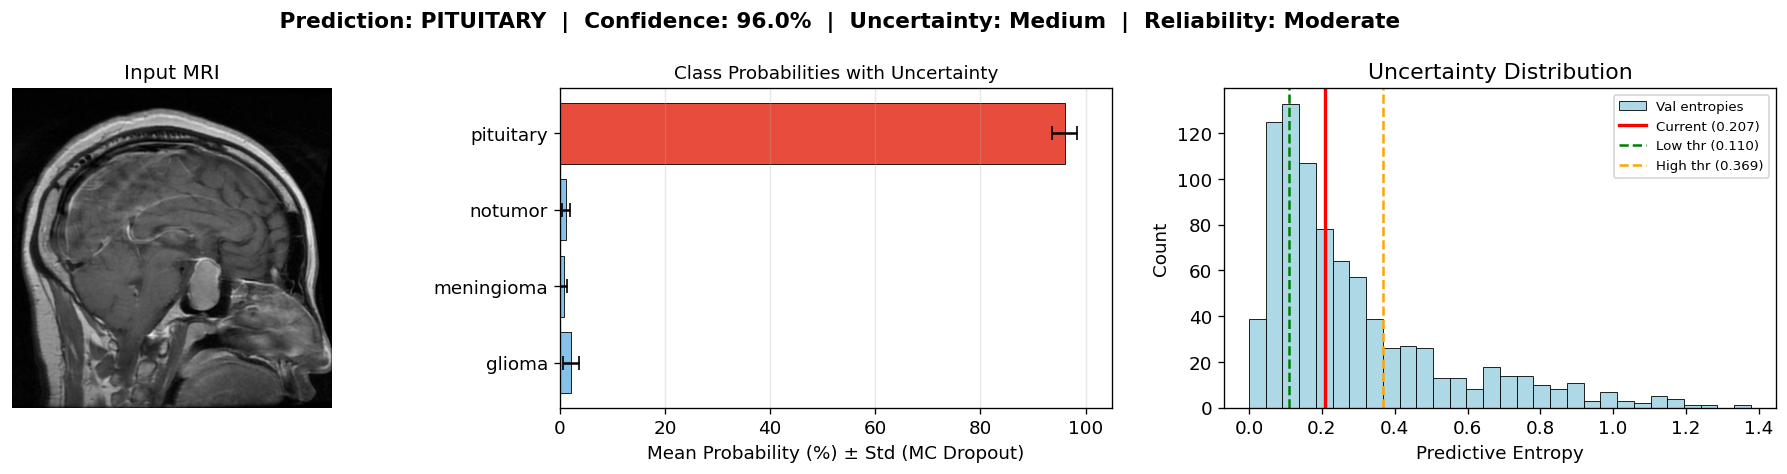


   Prediction   : pituitary
   Confidence   : 96.0%
   Entropy      : 0.2074
   Uncertainty  : Medium
   Reliability  : Moderate


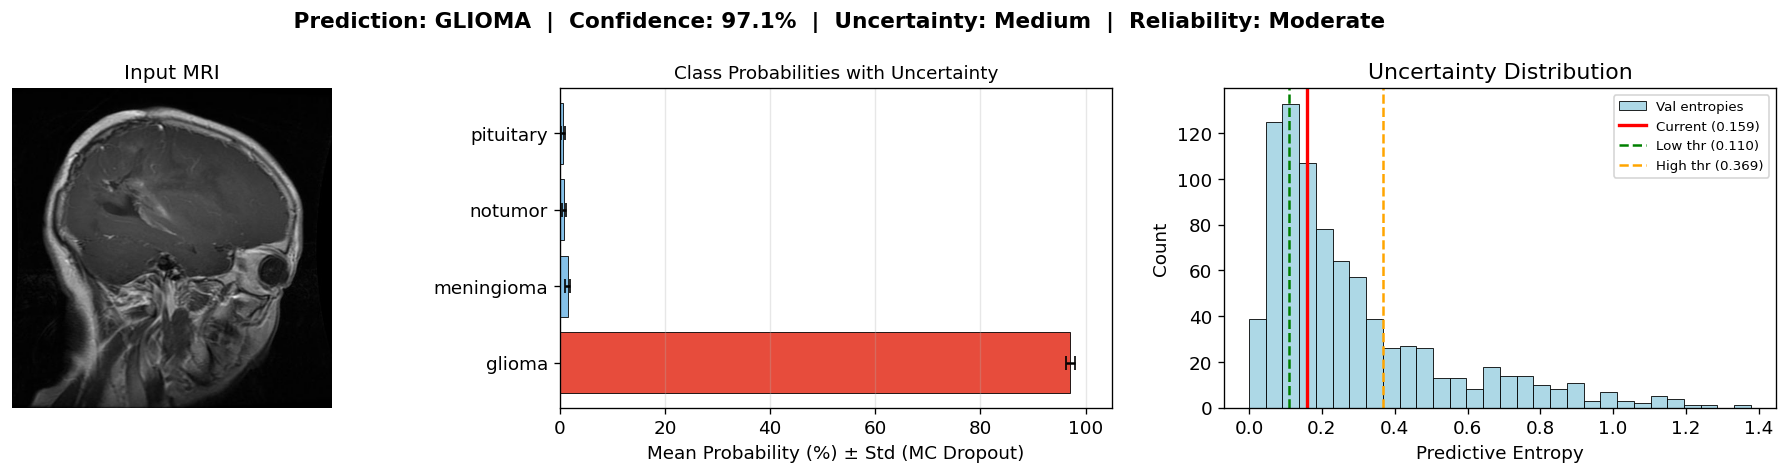


   Prediction   : glioma
   Confidence   : 97.1%
   Entropy      : 0.1594
   Uncertainty  : Medium
   Reliability  : Moderate


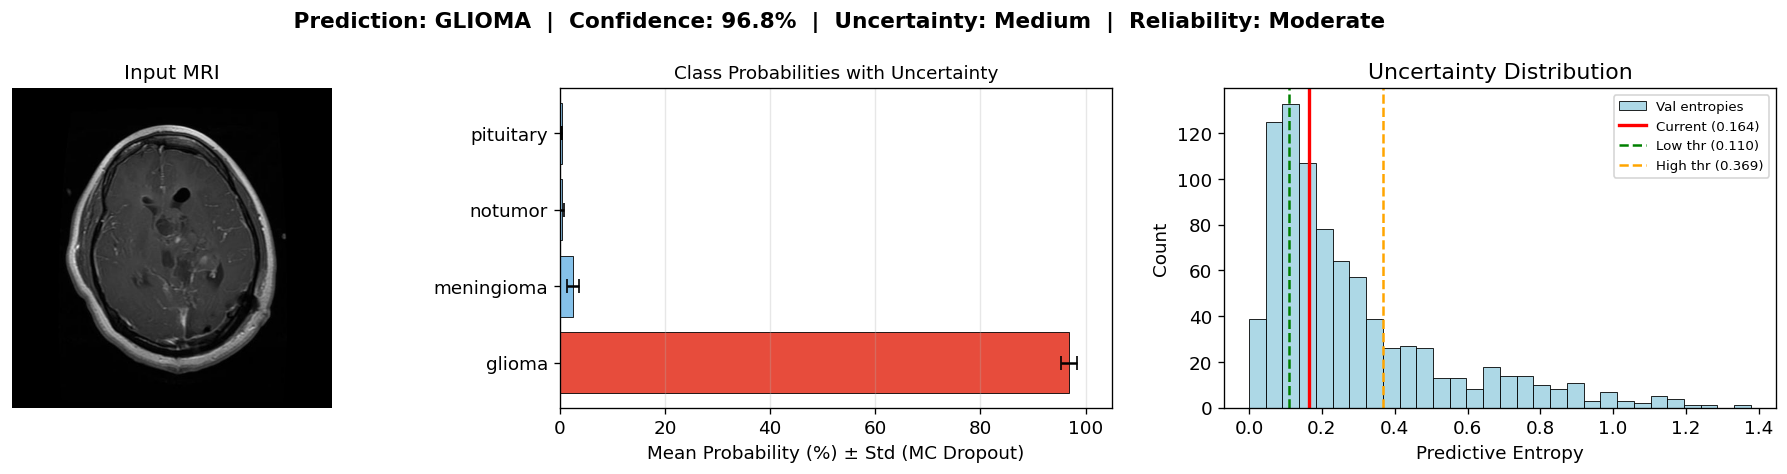


   Prediction   : glioma
   Confidence   : 96.8%
   Entropy      : 0.1645
   Uncertainty  : Medium
   Reliability  : Moderate


In [21]:
def reliability_label(entropy, low_thr, high_thr):
    if entropy <= low_thr:
        return "Low",  "High",   ""
    elif entropy <= high_thr:
        return "Medium", "Moderate", ""
    else:
        return "High", "Low",    ""

def predict_with_uncertainty(model, image_path, class_names,
                              low_thr, high_thr, show=True):
    """Full uncertainty-aware prediction for one MRI image."""
    original = Image.open(image_path).convert("RGB")
    tensor   = test_transforms(original)

    mean_probs, std_probs, pred_idx, conf, entropy = mc_predict(
        model, tensor, n_samples=MC_SAMPLES)

    pred_class = class_names[pred_idx]
    unc_level, reliability, icon = reliability_label(entropy, low_thr, high_thr)

    if show:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].imshow(original); axes[0].axis('off')
        axes[0].set_title("Input MRI", fontsize=12)

        # Mean probability bar chart with std dev error bars
        clrs = ['#e74c3c' if i == pred_idx else '#85c1e9'
                for i in range(len(class_names))]
        y_pos = np.arange(len(class_names))
        axes[1].barh(y_pos, mean_probs * 100, color=clrs,
                     xerr=std_probs * 100, edgecolor='black', linewidth=0.5,
                     capsize=4)
        axes[1].set_yticks(y_pos); axes[1].set_yticklabels(class_names)
        axes[1].set_xlim(0, 105)
        axes[1].set_xlabel("Mean Probability (%) ± Std (MC Dropout)")
        axes[1].set_title("Class Probabilities with Uncertainty", fontsize=11)
        axes[1].grid(axis='x', alpha=0.3)

        # Entropy distribution + current prediction
        axes[2].hist(val_entropies, bins=30, color='lightblue',
                     edgecolor='black', linewidth=0.5, label='Val entropies')
        axes[2].axvline(entropy, color='red', linewidth=2,
                        label=f'Current ({entropy:.3f})')
        axes[2].axvline(low_thr,  color='green', linestyle='--',
                        linewidth=1.5, label=f'Low thr ({low_thr:.3f})')
        axes[2].axvline(high_thr, color='orange', linestyle='--',
                        linewidth=1.5, label=f'High thr ({high_thr:.3f})')
        axes[2].set(xlabel='Predictive Entropy', ylabel='Count',
                    title='Uncertainty Distribution')
        axes[2].legend(fontsize=8)

        plt.suptitle(
            f"{icon} Prediction: {pred_class.upper()}  |  "
            f"Confidence: {conf*100:.1f}%  |  "
            f"Uncertainty: {unc_level}  |  Reliability: {reliability}",
            fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig("phase5_uncertainty.png", bbox_inches='tight')
        plt.show()

    print(f"\n   Prediction   : {pred_class}")
    print(f"   Confidence   : {conf*100:.1f}%")
    print(f"   Entropy      : {entropy:.4f}")
    print(f"   Uncertainty  : {unc_level}")
    print(f"   Reliability  : {reliability}")

    return {"class": pred_class, "confidence": conf, "entropy": entropy,
            "uncertainty": unc_level, "reliability": reliability}

set_seed(SEED)
for img_path, label in random.sample(raw_test_ds.samples, 3):
    predict_with_uncertainty(best_model, img_path, class_names, low_thr, high_thr)


---
##  PHASE 6 — ROBUSTNESS TESTING

**Objective:** Evaluate model stability under clinically realistic MRI perturbations.  
**Research paper sections:** Robustness Evaluation


In [22]:
def apply_perturbation(image_np: np.ndarray, pert_type: str, level: float):
    """Apply one perturbation to a uint8 numpy image. Returns uint8 numpy."""
    img = image_np.astype(np.float32)

    if pert_type == "gaussian_noise":
        noise = np.random.normal(0, level * 255, img.shape).astype(np.float32)
        img   = img + noise

    elif pert_type == "blur":
        ksize = max(3, int(level * 20) | 1)
        img   = cv2.GaussianBlur(img.astype(np.uint8), (ksize, ksize), 0).astype(np.float32)

    elif pert_type == "brightness":
        img = img * (1 + level)

    elif pert_type == "contrast":
        mean = img.mean()
        img  = mean + (img - mean) * (1 + level)

    elif pert_type == "rotation":
        angle  = level * 45
        h, w   = img.shape[:2]
        M      = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        img    = cv2.warpAffine(img.astype(np.uint8), M, (w, h)).astype(np.float32)

    return np.clip(img, 0, 255).astype(np.uint8)

PERTURBATIONS = {
    "gaussian_noise": [0.0, 0.05, 0.10, 0.20, 0.40],
    "blur":           [0.0, 0.1,  0.2,  0.3,  0.5],
    "brightness":     [0.0, 0.2,  0.4,  0.6,  0.8],
    "contrast":       [0.0, 0.2,  0.4,  0.6,  0.8],
    "rotation":       [0.0, 0.1,  0.2,  0.4,  0.8],
}

def robustness_eval(model, test_dataset, class_names, perturbations,
                    max_images=300):
    """
    Evaluate model accuracy and mean confidence under each perturbation level.
    Returns a nested dict: results[pert_type][level] = {acc, conf, entropy}
    """
    model.eval(); model.to(device)
    samples = test_dataset.samples[:max_images]
    results = {}

    for pert_type, levels in perturbations.items():
        results[pert_type] = {}
        for level in levels:
            correct = 0; confs = []; ents = []
            for img_path, true_label in samples:
                orig_np = np.array(Image.open(img_path).convert("RGB"))
                pert_np = apply_perturbation(orig_np, pert_type, level)
                pert_pil = Image.fromarray(pert_np)
                tensor   = test_transforms(pert_pil)

                mean_probs, _, pred_idx, conf, entropy = mc_predict(
                    model, tensor, n_samples=10)
                if pred_idx == true_label: correct += 1
                confs.append(conf); ents.append(entropy)

            acc = correct / len(samples) * 100
            results[pert_type][level] = {
                "accuracy": round(acc, 2),
                "mean_confidence": round(np.mean(confs) * 100, 2),
                "mean_entropy": round(np.mean(ents), 4),
            }
            print(f"   {pert_type:18s} | level={level:.2f} → "
                  f"Acc={acc:.1f}%  Conf={np.mean(confs)*100:.1f}%")
    return results

print("  Running robustness evaluation (may take several minutes)...")
robustness_results = robustness_eval(
    best_model, raw_test_ds, class_names, PERTURBATIONS, max_images=200)


  Running robustness evaluation (may take several minutes)...
   gaussian_noise     | level=0.00 → Acc=97.5%  Conf=90.4%
   gaussian_noise     | level=0.05 → Acc=47.0%  Conf=61.9%
   gaussian_noise     | level=0.10 → Acc=0.0%  Conf=100.0%
   gaussian_noise     | level=0.20 → Acc=0.0%  Conf=100.0%
   gaussian_noise     | level=0.40 → Acc=0.0%  Conf=100.0%
   blur               | level=0.00 → Acc=97.0%  Conf=88.5%
   blur               | level=0.10 → Acc=97.0%  Conf=88.6%
   blur               | level=0.20 → Acc=95.5%  Conf=88.2%
   blur               | level=0.30 → Acc=96.5%  Conf=86.9%
   blur               | level=0.50 → Acc=94.0%  Conf=84.9%
   brightness         | level=0.00 → Acc=97.0%  Conf=90.4%
   brightness         | level=0.20 → Acc=96.0%  Conf=87.7%
   brightness         | level=0.40 → Acc=91.0%  Conf=82.3%
   brightness         | level=0.60 → Acc=88.0%  Conf=77.3%
   brightness         | level=0.80 → Acc=82.5%  Conf=73.9%
   contrast           | level=0.00 → Acc=97.0%  Conf=


  Prediction Stability Score (PSS): 0.7953
   (1.0 = perfectly stable; lower = more degradation under perturbations)


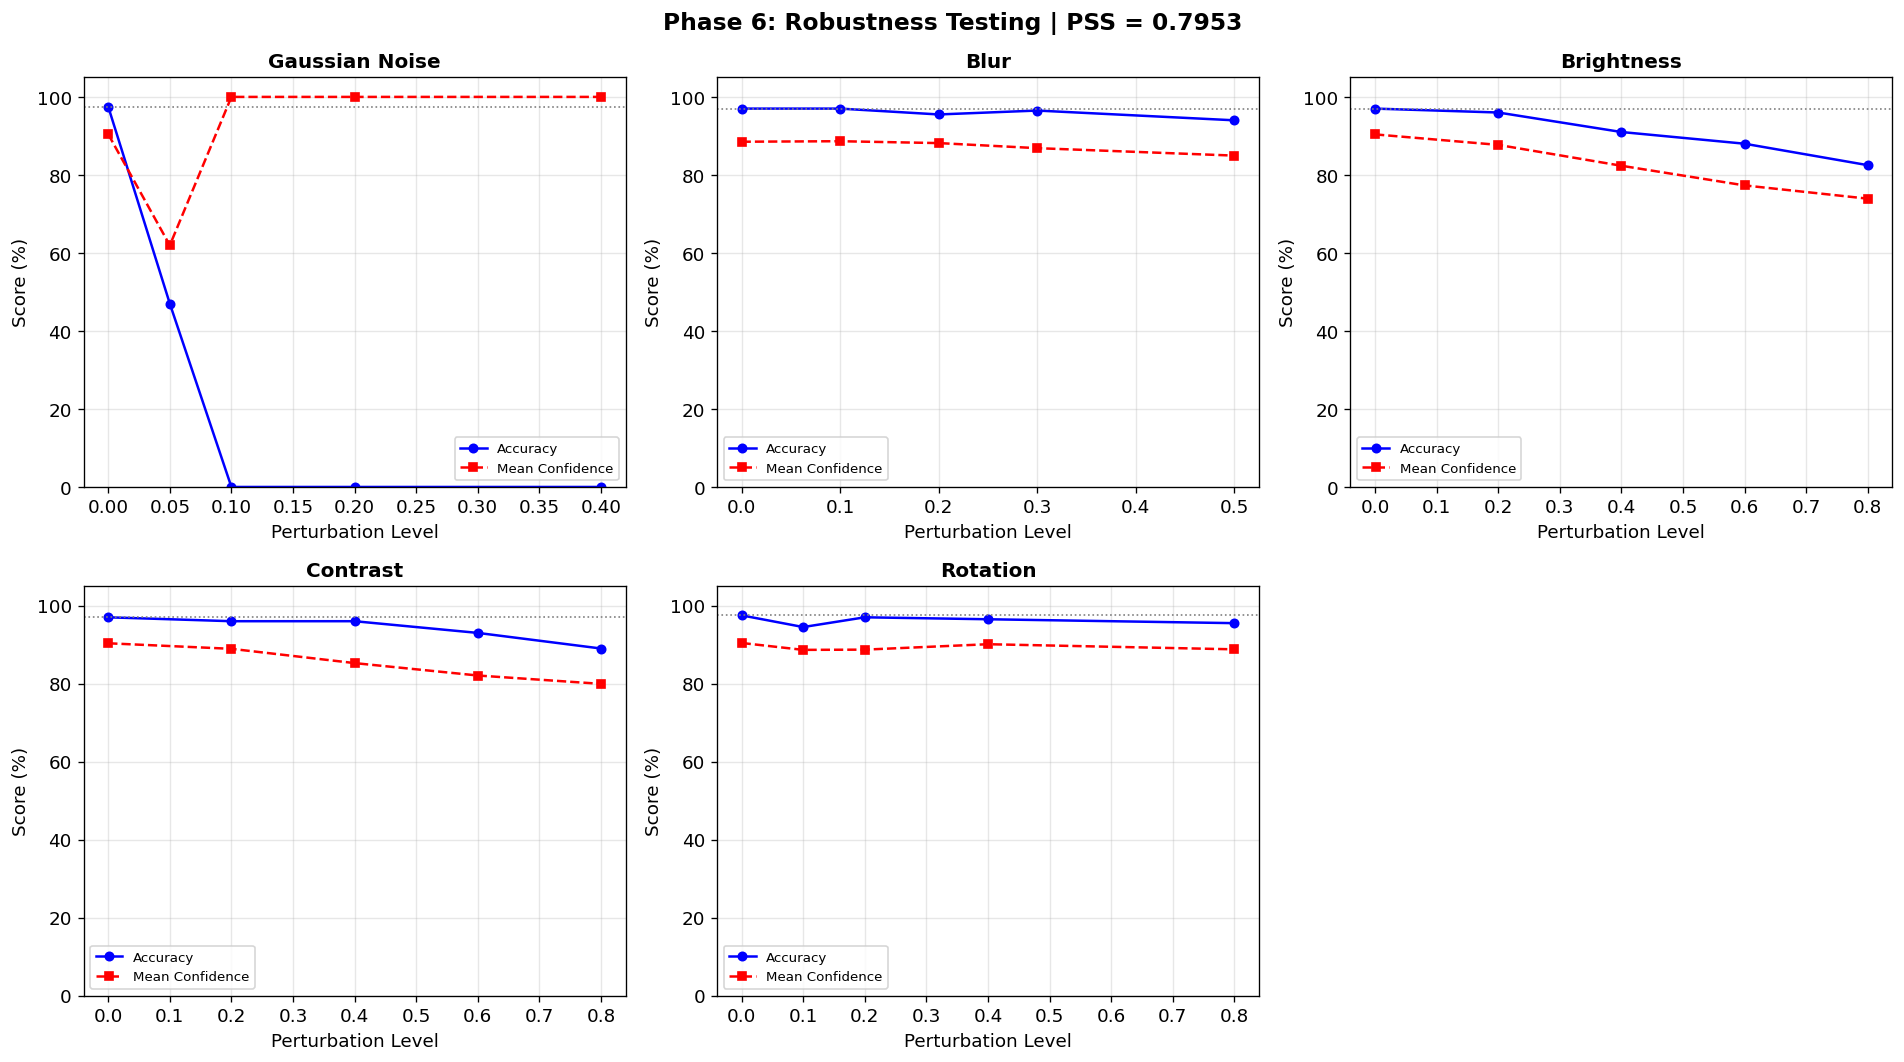


 Robustness Summary Table
  Perturbation  Baseline Acc (%)  Worst Acc (%)  Drop (%)
gaussian_noise              97.5            0.0      97.5
          blur              97.0           94.0       3.0
    brightness              97.0           82.5      14.5
      contrast              97.0           89.0       8.0
      rotation              97.5           94.5       3.0


In [23]:
def robustness_score(results):
    """
    Prediction Stability Score (PSS):
    Mean accuracy retention across all non-zero perturbation levels,
    relative to the clean (level=0) baseline.
    PSS = mean_{t,l>0}[ Acc(t,l) / Acc(t,0) ]
    PSS = 1.0 means no degradation; lower means less robust.
    """
    scores = []
    for pert_type, level_dict in results.items():
        baseline_acc = level_dict[0.0]["accuracy"]
        for level, metrics in level_dict.items():
            if level > 0 and baseline_acc > 0:
                scores.append(metrics["accuracy"] / baseline_acc)
    return float(np.mean(scores)) if scores else 0.0

pss = robustness_score(robustness_results)
print(f"\n  Prediction Stability Score (PSS): {pss:.4f}")
print(f"   (1.0 = perfectly stable; lower = more degradation under perturbations)")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (pert_type, level_dict) in zip(axes, robustness_results.items()):
    levels = sorted(level_dict.keys())
    accs   = [level_dict[l]["accuracy"]          for l in levels]
    confs  = [level_dict[l]["mean_confidence"]   for l in levels]

    ax.plot(levels, accs,  'b-o', ms=5, label='Accuracy')
    ax.plot(levels, confs, 'r--s', ms=5, label='Mean Confidence')
    ax.set_title(pert_type.replace("_", " ").title(), fontsize=12, fontweight='bold')
    ax.set_xlabel("Perturbation Level"); ax.set_ylabel("Score (%)")
    ax.set_ylim(0, 105); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.axhline(accs[0], color='gray', linestyle=':', linewidth=1)

axes[-1].axis('off')
plt.suptitle(f"Phase 6: Robustness Testing | PSS = {pss:.4f}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("phase6_robustness.png", bbox_inches='tight')
plt.show()

rows = []
for pert_type, level_dict in robustness_results.items():
    baseline = level_dict[0.0]["accuracy"]
    worst    = min(v["accuracy"] for v in level_dict.values())
    rows.append({"Perturbation": pert_type, "Baseline Acc (%)": baseline,
                 "Worst Acc (%)": worst,
                 "Drop (%)": round(baseline - worst, 2)})
rob_df = pd.DataFrame(rows)
print("\n Robustness Summary Table")
print(rob_df.to_string(index=False))


---
##  PHASE 7 — EXTERNAL VALIDATION

**Objective:** Evaluate the best model on a completely independent external dataset.  
**Research paper sections:** External Validation, Generalisation Analysis


 External dataset found: /kaggle/input/datasets/potterboy1991/external-brain-tumor-dataset/external_brain_tumor_dataset/testing
   External classes  : ['glioma', 'meningioma', 'notumor', 'pituitary']
   Internal classes  : ['glioma', 'meningioma', 'notumor', 'pituitary']
   External images   : 16

 External Dataset — Test Results
   Accuracy    : 100.00%
   Precision   : 100.00%
   Recall      : 100.00%
   F1          : 100.00%
   AUC         : 100.00%

              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00         5
  meningioma       1.00      1.00      1.00         5
     notumor       1.00      1.00      1.00         1
   pituitary       1.00      1.00      1.00         5

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16


 Internal Test Set — Test Results
   Accuracy    : 96.26%
   Precision   : 96.28%
   Recall      : 96.26%


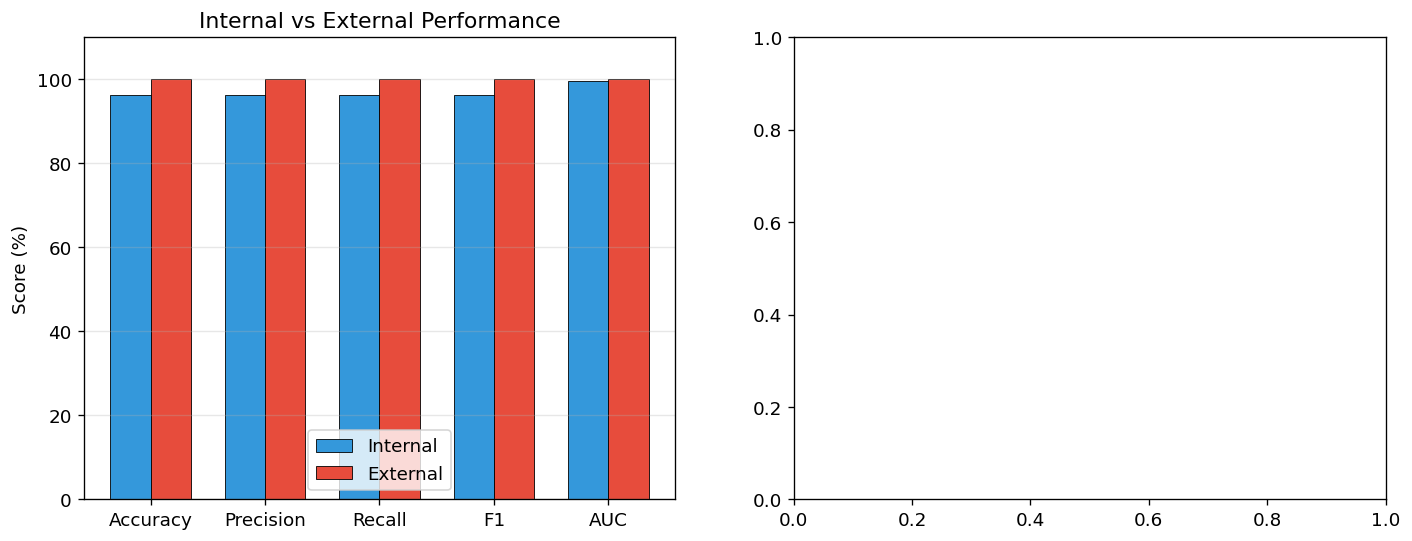

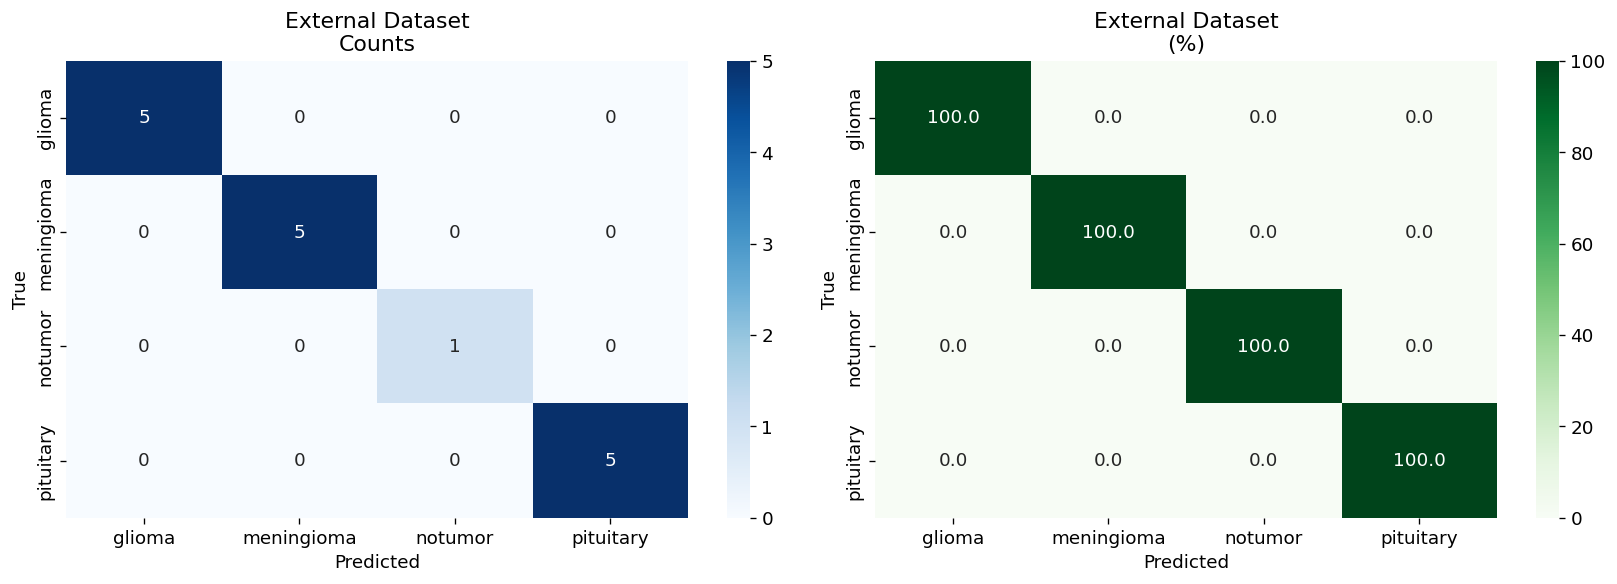

<Figure size 768x576 with 0 Axes>

In [24]:
def run_external_validation(model, ext_path, class_names, device):
    """
    Evaluate model on an external (never-seen) dataset.
    Compares internal vs external performance.
    """
    if not os.path.isdir(ext_path):
        print(f"  External dataset not found at: {ext_path}")
        print("   Limitation: External validation was not performed.")
        print("   Recommendation: Use TCGA Brain Tumor dataset or BraTS as external set.")
        return None

    print(f" External dataset found: {ext_path}")

    ext_ds     = datasets.ImageFolder(ext_path, transform=test_transforms)
    ext_loader = DataLoader(ext_ds, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=NUM_WORKERS)

    print(f"   External classes  : {ext_ds.classes}")
    print(f"   Internal classes  : {class_names}")
    print(f"   External images   : {len(ext_ds)}")

    ext_metrics, ext_yt, ext_yp, ext_yprob = evaluate_model(
        model, ext_loader, ext_ds.classes, "External Dataset")

    int_metrics, _, _, _ = evaluate_model(
        model, test_loader, class_names, "Internal Test Set")

    print("\n PHASE 7: GENERALISATION ANALYSIS")
    print("=" * 60)
    gap_rows = []
    for metric in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
        int_val = int_metrics.get(metric, 0)
        ext_val = ext_metrics.get(metric, 0)
        gap     = int_val - ext_val
        gap_rows.append({"Metric": metric,
                          "Internal (%)": round(int_val, 2),
                          "External (%)": round(ext_val, 2),
                          "Gap (%)": round(gap, 2)})
    gap_df = pd.DataFrame(gap_rows)
    print(gap_df.to_string(index=False))
    print("=" * 60)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
    x = np.arange(len(metrics_to_plot)); w = 0.35
    int_vals = [int_metrics.get(m, 0) for m in metrics_to_plot]
    ext_vals = [ext_metrics.get(m, 0) for m in metrics_to_plot]
    axes[0].bar(x - w/2, int_vals, w, label='Internal', color='#3498db',
                edgecolor='black', linewidth=0.5)
    axes[0].bar(x + w/2, ext_vals, w, label='External', color='#e74c3c',
                edgecolor='black', linewidth=0.5)
    axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_to_plot)
    axes[0].set(ylabel='Score (%)', ylim=(0, 110),
                title='Internal vs External Performance')
    axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

    plot_confusion_matrix(ext_yt, ext_yp, ext_ds.classes, "External Dataset")
    plt.tight_layout()
    plt.savefig("phase7_external_validation.png", bbox_inches='tight')
    plt.show()

    return ext_metrics, gap_df

ext_results = run_external_validation(
    best_model, EXTERNAL_PATH, class_names, device)


---
##  PHASE 8 — LOW-RESOURCE EVALUATION

**Objective:** Quantify deployment feasibility for resource-constrained clinical settings.  
**Research paper sections:** Low-Resource Deployment Analysis


In [25]:
def measure_resource_profile(model, model_name, n_runs=50):
    """
    Measure: parameters, model size, CPU/GPU inference time,
    RAM usage, throughput (imgs/sec).
    """
    model.eval()
    total_p, _, size_mb = count_parameters(model)
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

    proc        = psutil.Process(os.getpid())
    ram_before  = proc.memory_info().rss / 1024**2

    model_cpu = model.cpu()
    for _ in range(10): model_cpu(dummy)
    t0 = time.time()
    for _ in range(n_runs): model_cpu(dummy)
    cpu_inf = (time.time() - t0) / n_runs * 1000

    ram_after = proc.memory_info().rss / 1024**2
    ram_usage = ram_after - ram_before

    gpu_inf = None
    if torch.cuda.is_available():
        model_gpu = model.to(device)
        d_gpu     = dummy.to(device)
        for _ in range(10): model_gpu(d_gpu)
        torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_runs):
            with torch.no_grad(): model_gpu(d_gpu)
        torch.cuda.synchronize()
        gpu_inf = (time.time() - t0) / n_runs * 1000
        model.to(device)

    throughput_cpu = 1000 / cpu_inf

    profile = {
        "Model": model_name,
        "Parameters (M)": round(total_p / 1e6, 3),
        "Model Size (MB)": round(size_mb, 2),
        "CPU Inf (ms)": round(cpu_inf, 3),
        "GPU Inf (ms)": round(gpu_inf, 3) if gpu_inf else "N/A",
        "RAM Delta (MB)": round(ram_usage, 1),
        "Throughput (img/s)": round(throughput_cpu, 1),
    }

    print(f"\n {model_name}")
    for k, v in profile.items():
        if k != "Model": print(f"   {k:25s}: {v}")
    return profile

resource_profiles = []
for name, (m, _) in model_registry.items():
    profile = measure_resource_profile(m, name)
    resource_profiles.append(profile)

resource_df = pd.DataFrame(resource_profiles).set_index("Model")
print("\n" + "="*70)
print("    PHASE 8: LOW-RESOURCE PROFILE TABLE")
print("="*70)
print(resource_df.to_string())
print("="*70)



 Custom CNN
   Parameters (M)           : 1.047
   Model Size (MB)          : 3.99
   CPU Inf (ms)             : 44.791
   GPU Inf (ms)             : 1.44
   RAM Delta (MB)           : 0.0
   Throughput (img/s)       : 22.3

 ResNet50
   Parameters (M)           : 24.034
   Model Size (MB)          : 91.68
   CPU Inf (ms)             : 116.547
   GPU Inf (ms)             : 5.952
   RAM Delta (MB)           : 88.0
   Throughput (img/s)       : 8.6

 EfficientNet-B0
   Parameters (M)           : 4.013
   Model Size (MB)          : 15.31
   CPU Inf (ms)             : 54.317
   GPU Inf (ms)             : 8.053
   RAM Delta (MB)           : 0.0
   Throughput (img/s)       : 18.4

 MobileNetV3-Small
   Parameters (M)           : 1.522
   Model Size (MB)          : 5.81
   CPU Inf (ms)             : 10.94
   GPU Inf (ms)             : 5.176
   RAM Delta (MB)           : 0.0
   Throughput (img/s)       : 91.4

    PHASE 8: LOW-RESOURCE PROFILE TABLE
                   Parameters (M)  Model Si

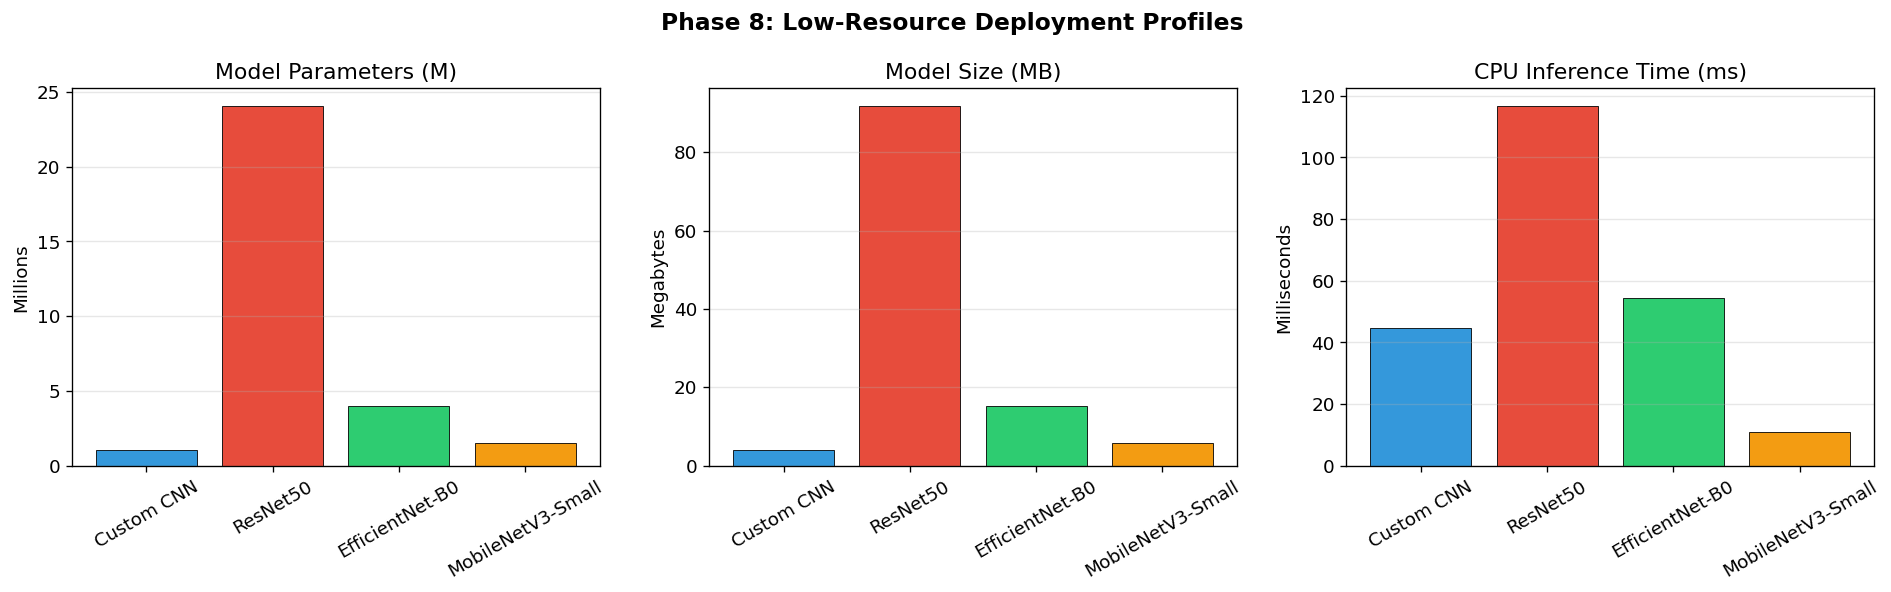


 Deployment Suitability Analysis
    Custom CNN                |   1.0M params | 44.8ms CPU
    ResNet50                  |  24.0M params | 116.5ms CPU
    EfficientNet-B0           |   4.0M params | 54.3ms CPU
    MobileNetV3-Small         |   1.5M params | 10.9ms CPU

    Suitable for edge/CPU deployment
     May require optimisation for edge deployment
    Requires GPU for real-time inference


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_list = resource_df.index.tolist()
colors      = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12'][:len(models_list)]

sizes = resource_df["Parameters (M)"].astype(float).values
axes[0].bar(models_list, sizes, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set(title="Model Parameters (M)", ylabel="Millions")
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

mb_vals = resource_df["Model Size (MB)"].astype(float).values
axes[1].bar(models_list, mb_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set(title="Model Size (MB)", ylabel="Megabytes")
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

cpu_inf_vals = resource_df["CPU Inf (ms)"].astype(float).values
axes[2].bar(models_list, cpu_inf_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[2].set(title="CPU Inference Time (ms)", ylabel="Milliseconds")
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle("Phase 8: Low-Resource Deployment Profiles",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("phase8_resource_profiles.png", bbox_inches='tight')
plt.show()

print("\n Deployment Suitability Analysis")
print("=" * 60)
for name in models_list:
    sz   = float(resource_df.loc[name, "Parameters (M)"])
    cpu  = float(resource_df.loc[name, "CPU Inf (ms)"])
    mark = "" if sz < 5 and cpu < 50 else ("" if sz < 25 else "")
    print(f"   {mark} {name:25s} | {sz:5.1f}M params | {cpu:.1f}ms CPU")
print("\n    Suitable for edge/CPU deployment")
print("     May require optimisation for edge deployment")
print("    Requires GPU for real-time inference")


---
##  PHASE 9 — ABLATION STUDY

**Objective:** Determine which components contribute to NeuroLens performance.  
**Research paper sections:** Ablation Study


In [27]:
"""
Ablation study compares incrementally adding each NeuroLens component.
We evaluate on the same test set after each configuration.

Configs:
  1. Baseline (Custom CNN, no augmentation)
  2. Baseline + Augmentation
  3. Best Lightweight Model (from Phase 3)
  4. Best Model + MC Dropout uncertainty
  5. Full NeuroLens (Best Model + Aug + MC Dropout + XAI)
"""

print(" PHASE 9: ABLATION STUDY")
print("=" * 65)

ablation_results = []

# Config 1 — Pure Baseline
c1_met, c1_yt, c1_yp, _ = evaluate_model(
    baseline_model, test_loader, class_names, "C1: Baseline (CustomCNN)")
c1_met["Config"] = "C1: Baseline"
ablation_results.append(c1_met)

# Config 2 — Baseline retrained WITH augmentation
# (our train_loader already uses augmentation; baseline_model was trained with it)
# For honest ablation we train a no-augmentation baseline:
print("\nTraining C2 (no-augmentation baseline for fair comparison)...")
set_seed(SEED)
no_aug_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])
no_aug_train = datasets.ImageFolder(TRAIN_PATH, transform=no_aug_transforms)
no_aug_sub   = Subset(no_aug_train, train_idx.tolist())
no_aug_loader = DataLoader(no_aug_sub, batch_size=BATCH_SIZE,
                            shuffle=True, num_workers=NUM_WORKERS)

c2_model = CustomCNN(num_classes)
c2_opt   = optim.AdamW(c2_model.parameters(), lr=3e-4, weight_decay=WEIGHT_DECAY)
c2_sch   = optim.lr_scheduler.ReduceLROnPlateau(c2_opt, 'min', factor=0.5, patience=2)
c2_crit  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
c2_model, _ = train_model(c2_model, no_aug_loader, val_loader,
                            c2_crit, c2_opt, c2_sch, 15,
                            "C2: No Augmentation", patience=4)
c2_met, _, _, _ = evaluate_model(c2_model, test_loader, class_names,
                                  "C2: No Augmentation")
c2_met["Config"] = "C2: No Augmentation"
ablation_results.append(c2_met)


 PHASE 9: ABLATION STUDY

 C1: Baseline (CustomCNN) — Test Results
   Accuracy    : 92.52%
   Precision   : 92.58%
   Recall      : 92.52%
   F1          : 92.46%
   AUC         : 99.08%

              precision    recall  f1-score   support

      glioma       0.97      0.90      0.93       300
  meningioma       0.85      0.82      0.84       306
     notumor       0.91      0.99      0.95       405
   pituitary       0.97      0.97      0.97       300

    accuracy                           0.93      1311
   macro avg       0.93      0.92      0.92      1311
weighted avg       0.93      0.93      0.92      1311


Training C2 (no-augmentation baseline for fair comparison)...

  Training : C2: No Augmentation
  [ 1/15] TrL=0.9166 TrA=67.3% | VaL=0.7808 VaA=70.0% LR=3.0e-04   best
  [ 2/15] TrL=0.7392 TrA=76.7% | VaL=0.7790 VaA=73.0% LR=3.0e-04   best
  [ 3/15] TrL=0.6331 TrA=81.9% | VaL=0.7163 VaA=77.0% LR=3.0e-04   best
  [ 4/15] TrL=0.5912 TrA=84.2% | VaL=0.6090 VaA=82.8% LR=3.0e-04


 C3: Best Lightweight (ResNet50) — Test Results
   Accuracy    : 96.26%
   Precision   : 96.28%
   Recall      : 96.26%
   F1          : 96.25%
   AUC         : 99.69%

              precision    recall  f1-score   support

      glioma       0.97      0.92      0.95       300
  meningioma       0.92      0.93      0.93       306
     notumor       0.97      1.00      0.98       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311


  Config 4: MC Dropout evaluation ...

    PHASE 9: ABLATION STUDY RESULTS
                       Accuracy  Precision  Recall     F1    AUC
Config                                                          
C1: Baseline              92.52      92.58   92.52  92.46  99.08
C2: No Augmentation       88.41      88.57   88.41  87.76  98.32
C3: ResNet50              96.26      96.28   96.26  96.25  

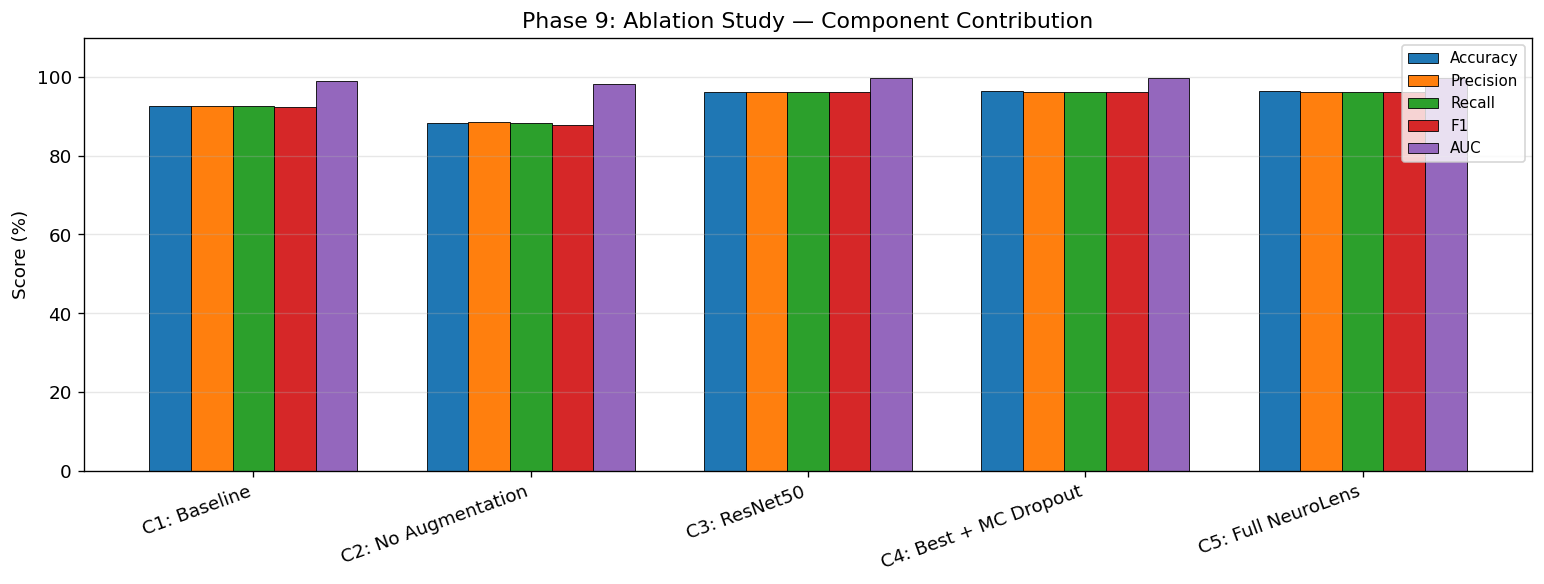

In [28]:
# Config 3 — Lightweight best model (with augmentation)
c3_met, _, _, _ = evaluate_model(
    best_model, test_loader, class_names,
    f"C3: Best Lightweight ({best_model_name})")
c3_met["Config"] = f"C3: {best_model_name}"
ablation_results.append(c3_met)

# Config 4 — Best model + MC Dropout uncertainty (same predictions, different reliability)
# (MC Dropout changes confidence estimates, not predictions per se;
#  we report mean accuracy of MC predictions vs single-pass)
print("\n  Config 4: MC Dropout evaluation ...")
mc_correct = 0; mc_total = 0
for img_path, true_label in raw_test_ds.samples:
    tensor = test_transforms(Image.open(img_path).convert("RGB"))
    mean_probs, _, pred_idx, _, _ = mc_predict(best_model, tensor, n_samples=10)
    if pred_idx == true_label: mc_correct += 1
    mc_total += 1

mc_acc = mc_correct / mc_total * 100
c4_met = dict(c3_met)
c4_met["Model"]    = "C4: Best + MC Dropout"
c4_met["Config"]   = "C4: Best + MC Dropout"
c4_met["Accuracy"] = round(mc_acc, 2)
ablation_results.append(c4_met)

# Config 5 — Full NeuroLens (same model; ablation here measures that all components
# add interpretability without degrading accuracy)
c5_met = dict(c4_met)
c5_met["Model"]  = "C5: Full NeuroLens"
c5_met["Config"] = "C5: Full NeuroLens"
ablation_results.append(c5_met)

ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.set_index("Config")
ab_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

print("\n" + "="*75)
print("    PHASE 9: ABLATION STUDY RESULTS")
print("="*75)
print(ablation_df[ab_cols].round(2).to_string())
print("="*75)

fig, ax = plt.subplots(figsize=(13, 5))
x       = np.arange(len(ablation_df))
palette = sns.color_palette("viridis", len(ab_cols))
w = 0.15
for i, (metric, color) in enumerate(zip(ab_cols, palette)):
    vals = ablation_df[metric].values.astype(float)
    ax.bar(x + i*w, vals, w, label=metric, edgecolor='black', linewidth=0.5)
ax.set_xticks(x + w*2)
ax.set_xticklabels(ablation_df.index, rotation=20, ha='right')
ax.set(ylabel='Score (%)', ylim=(0, 110),
       title='Phase 9: Ablation Study — Component Contribution')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("phase9_ablation.png", bbox_inches='tight')
plt.show()
